# **Generazione e riconoscimento di tonalità DTMF**

### **Import delle librerie**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft
import os
from src.DTMF_implementation import (
    plot_all_tones_grid,
    dialNumber,
    plot_and_save_sequence,
    plot_spectrum,
    recNumber,
    recSequence,
    dialNumber_pauses,
    detect_sequence_pauses
)
from src.experiments.duration import run_duration_experiments
from src.experiments.noise import run_noise_experiments
from src.experiments.sampling import run_sampling_experiments
from src.improvements.denoising import run_denoising_experiments
from src.improvements.zero_padding import run_zeropadding_experiments

### **Configurazione struttura cartelle di salvataggio figure + file .wav**

In [2]:
PLOTS_BASE = "Plots"

# Sottocartelle principali
PLOTS_IMPLEMENTATION = os.path.join(PLOTS_BASE, "DTMF_implementation")
PLOTS_EXPERIMENTS = os.path.join(PLOTS_BASE, "experiments")
PLOTS_IMPROVEMENTS = os.path.join(PLOTS_BASE, "improvements")

# Sottocartelle esperimenti
PLOTS_NOISE = os.path.join(PLOTS_EXPERIMENTS, "noise")
PLOTS_DURATION = os.path.join(PLOTS_EXPERIMENTS, "duration")
PLOTS_SAMPLING = os.path.join(PLOTS_EXPERIMENTS, "sampling")

# Sottocartelle miglioramenti
PLOTS_DENOISING = os.path.join(PLOTS_IMPROVEMENTS, "denoising")
PLOTS_ZEROPADDING = os.path.join(PLOTS_IMPROVEMENTS, "zero_padding")

# Cartelle per file audio WAV
AUDIO_BASE = "Audio"
AUDIO_TONES = os.path.join(AUDIO_BASE, "tones")
AUDIO_SEQUENCES = os.path.join(AUDIO_BASE, "sequences")

# Creazione di tutte le cartelle
folders = [
    PLOTS_BASE,
    PLOTS_IMPLEMENTATION,
    PLOTS_EXPERIMENTS,
    PLOTS_IMPROVEMENTS,
    PLOTS_NOISE,
    PLOTS_DURATION,
    PLOTS_SAMPLING,
    PLOTS_DENOISING,
    PLOTS_ZEROPADDING,
    AUDIO_BASE,
    AUDIO_TONES,
    AUDIO_SEQUENCES
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

## **1. Implementazione DTMF**

### **1.1 Creazione del dizionario**

In [3]:
# Definizione delle frequenze DTMF (Standard ETSI)
F1 = np.array([697, 770, 852, 941])      # Frequenze basse (righe)
F2 = np.array([1209, 1336, 1477, 1633])  # Frequenze alte (colonne)

# Definizione del dizionario dei toni
tones = {
    '1': (0, 0), '2': (0, 1), '3': (0, 2), 'A': (0, 3),
    '4': (1, 0), '5': (1, 1), '6': (1, 2), 'B': (1, 3),
    '7': (2, 0), '8': (2, 1), '9': (2, 2), 'C': (2, 3),
    '*': (3, 0), '0': (3, 1), '#': (3, 2), 'D': (3, 3)
}

# Visualizzazione del dizionario
print("Dizionario toni DTMF:")
print(tones)

# Visualizzazione matrice frequenze
print("\nMatrice frequenze DTMF:")
print(f"{'':>5} | {F2[0]:>6} Hz | {F2[1]:>6} Hz | {F2[2]:>6} Hz | {F2[3]:>6} Hz")
print("-" * 60)
for i, f1 in enumerate(F1):
    row = [key for key, (r, c) in tones.items() if r == i]
    print(f"{f1:>3} Hz | {row[0]:>8} | {row[1]:>8} | {row[2]:>8} | {row[3]:>8}")

Dizionario toni DTMF:
{'1': (0, 0), '2': (0, 1), '3': (0, 2), 'A': (0, 3), '4': (1, 0), '5': (1, 1), '6': (1, 2), 'B': (1, 3), '7': (2, 0), '8': (2, 1), '9': (2, 2), 'C': (2, 3), '*': (3, 0), '0': (3, 1), '#': (3, 2), 'D': (3, 3)}

Matrice frequenze DTMF:
      |   1209 Hz |   1336 Hz |   1477 Hz |   1633 Hz
------------------------------------------------------------
697 Hz |        1 |        2 |        3 |        A
770 Hz |        4 |        5 |        6 |        B
852 Hz |        7 |        8 |        9 |        C
941 Hz |        * |        0 |        # |        D


#### **Parametri di campionamento globali**

In [4]:
Fs = 8000          # Frequenza di campionamento [Hz]
toneDuration = 0.15  # Durata standard dei toni [s]

print(f"Frequenza di campionamento: {Fs} Hz")
print(f"Durata toni: {toneDuration} s")
print(f"Campioni per tono: {int(Fs * toneDuration)}")

Frequenza di campionamento: 8000 Hz
Durata toni: 0.15 s
Campioni per tono: 1200


### **1.2 Esempio applicativo**

#### **Visualizzazione di tutti i toni DTMF nel dominio del tempo e della frequenza**

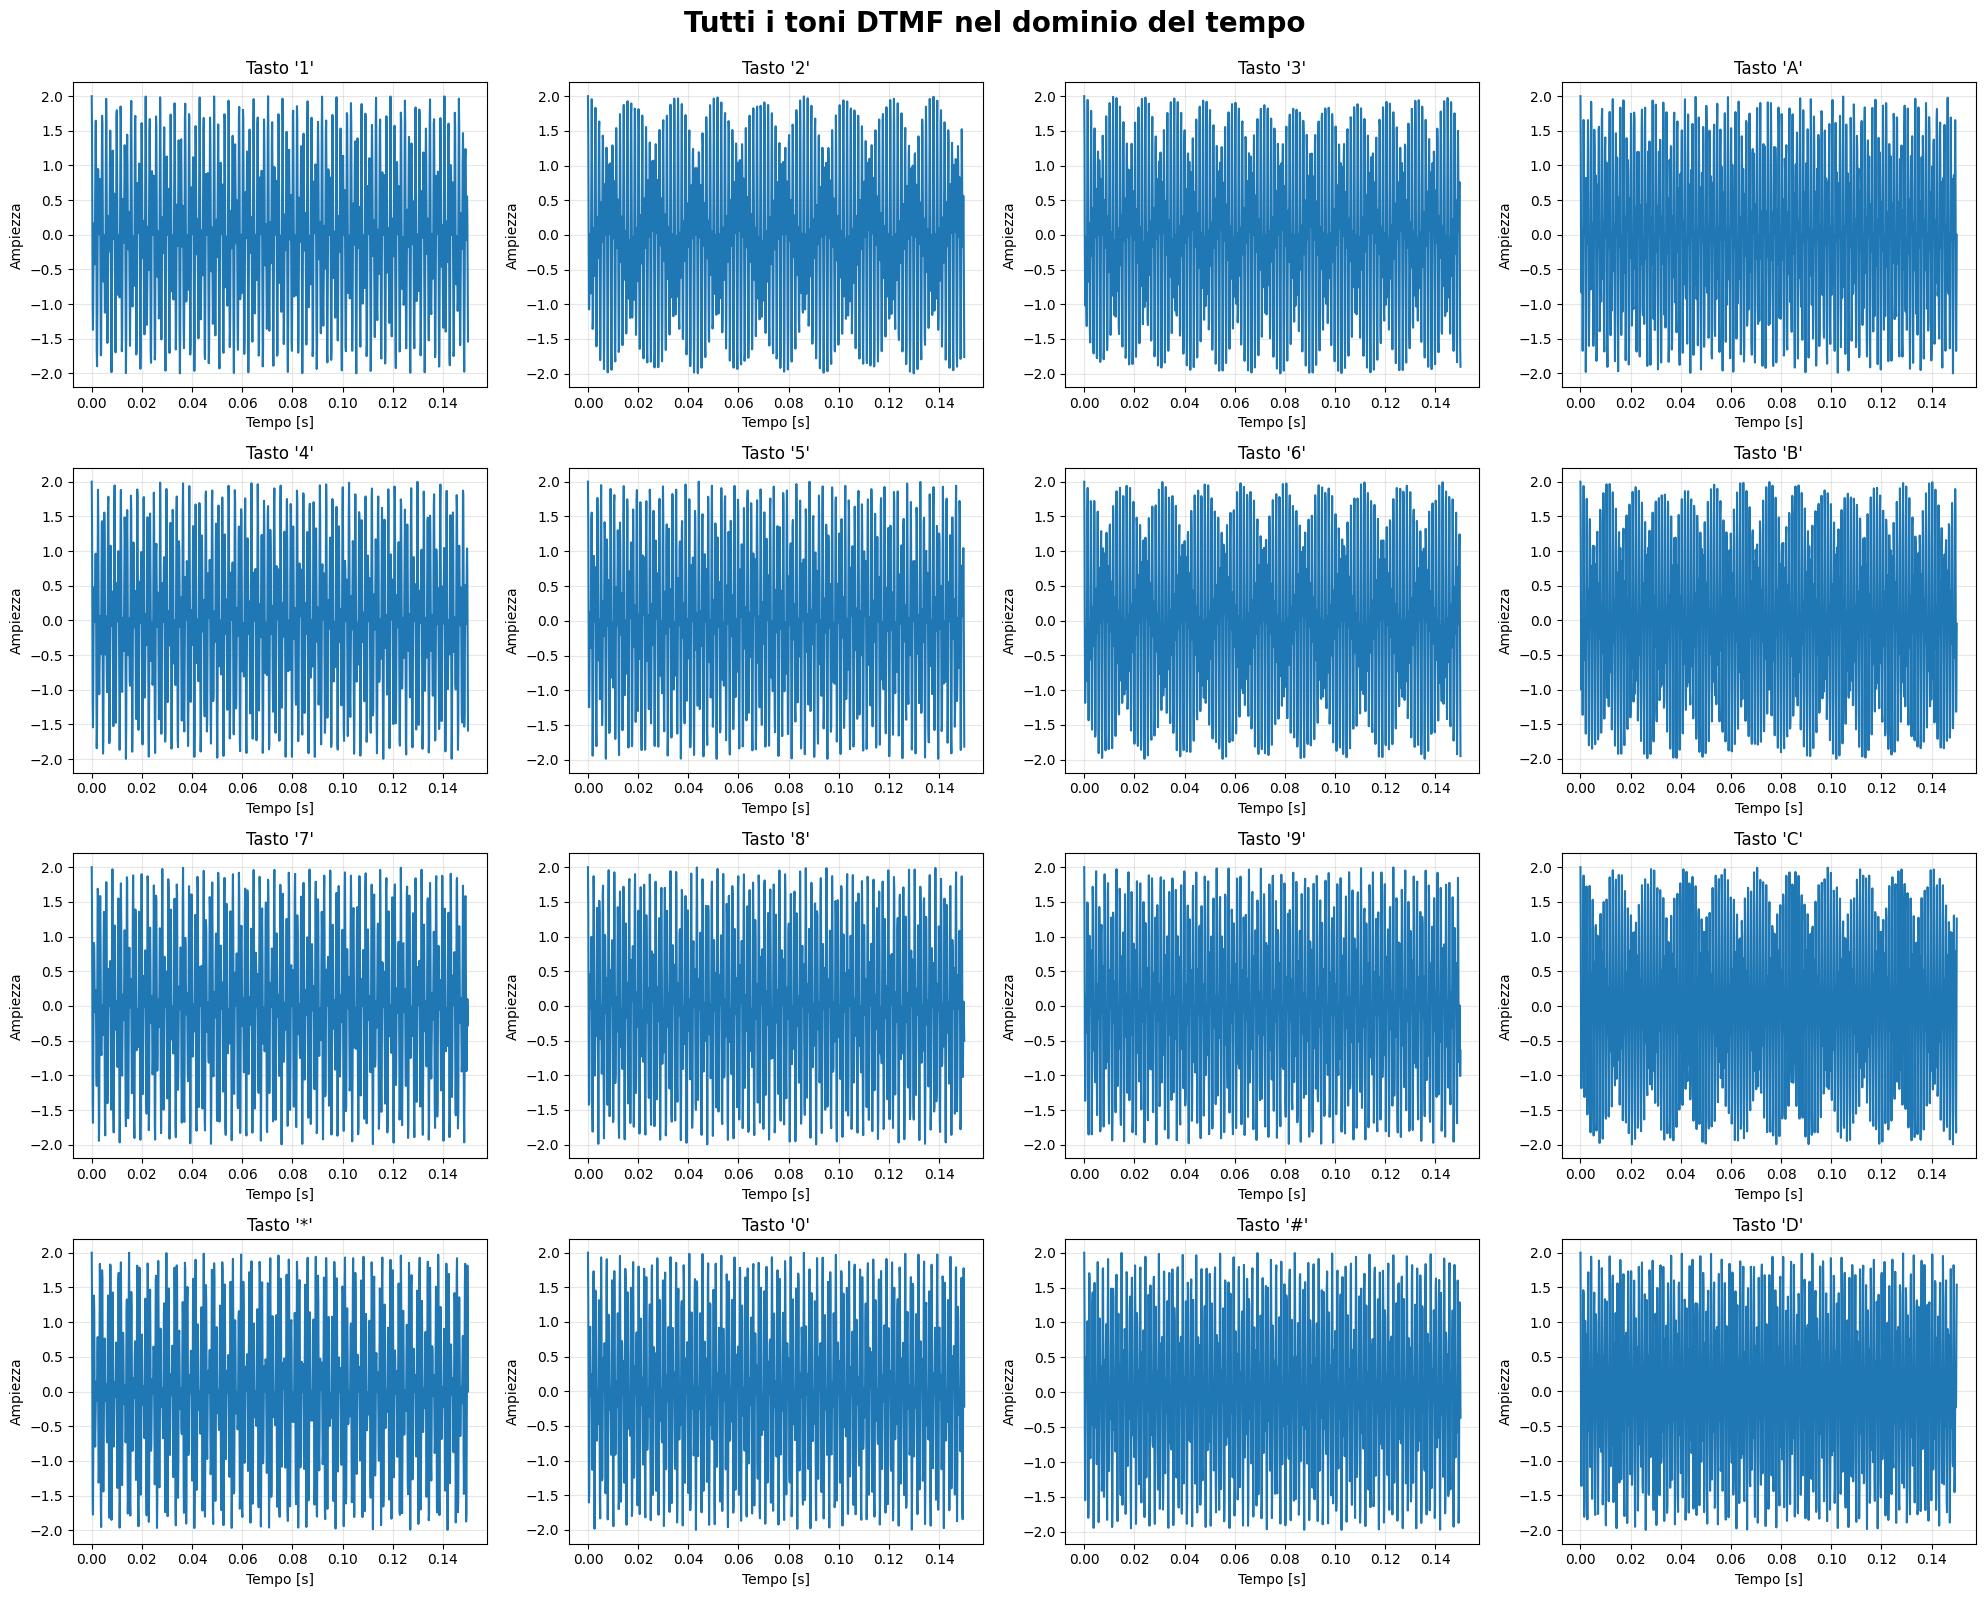

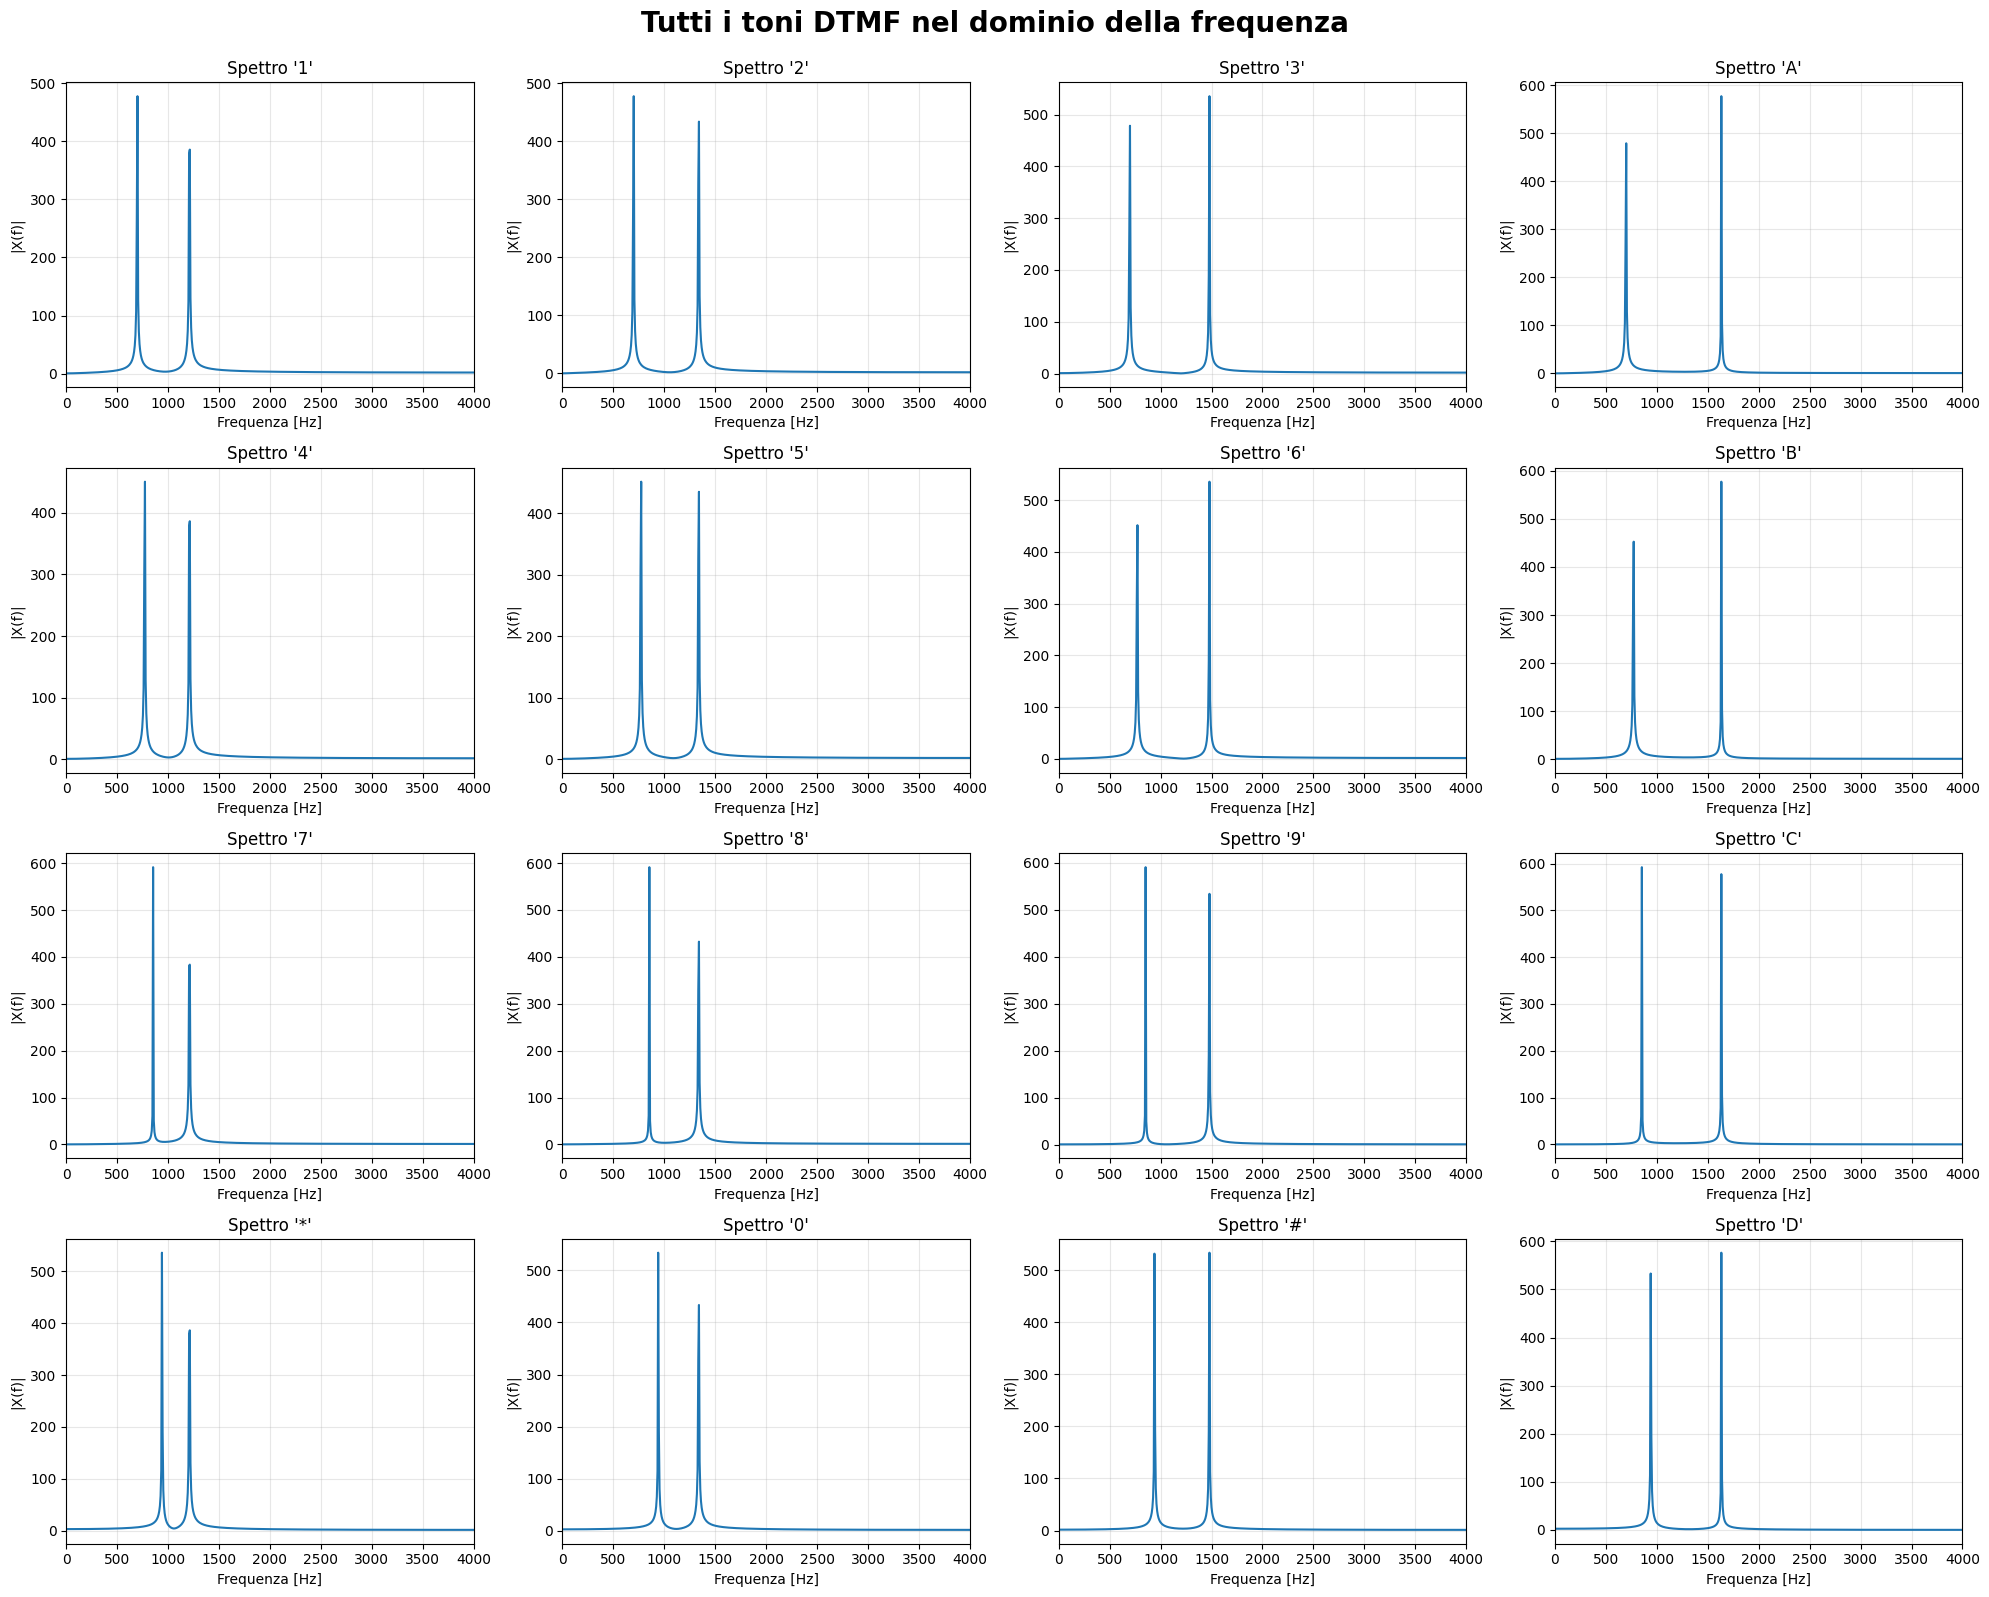

Plot salvati in: Plots/DTMF_implementation/


In [5]:
plot_all_tones_grid(duration=toneDuration, Fs=Fs, plot_folder=PLOTS_IMPLEMENTATION)

#### **Generazione e visualizzazione della sequenza '3456318060'**

Plot salvato in: Plots/DTMF_implementation/sequenza.pdf


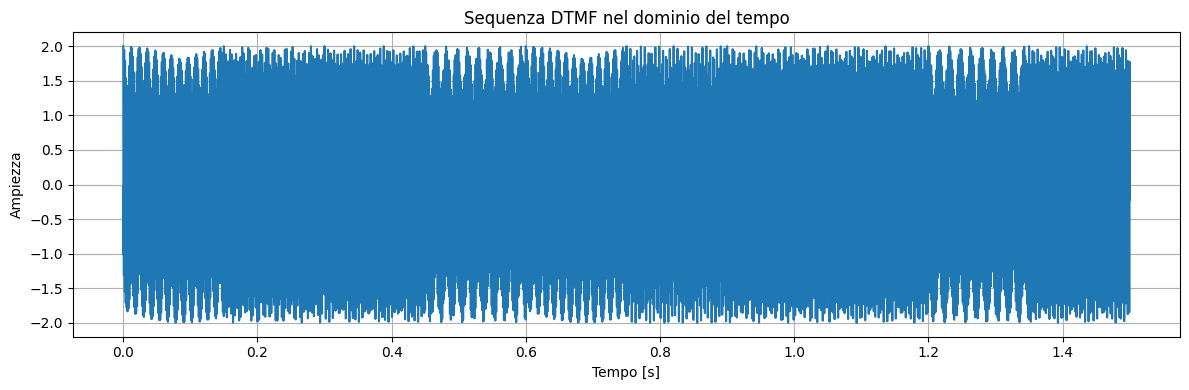

Audio salvato: Audio/sequences/sequenza.wav
Plot salvato in: Plots/DTMF_implementation/spettro_sequenza.pdf


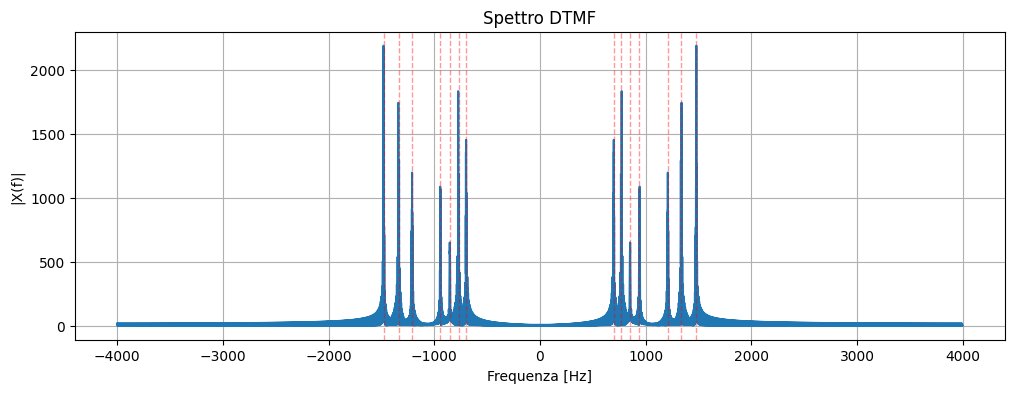

(array([-4000.        , -3999.33333333, -3998.66666667, ...,
         3998.        ,  3998.66666667,  3999.33333333]),
 array([17.50205654-0.j        , -0.43774436-1.24140538j,
         0.0816677 +0.15751167j, ..., -0.41925794-0.93530485j,
         0.0816677 -0.15751167j, -0.43774436+1.24140538j]))

In [6]:
# Generazione della sequenza
sequenza = "3456318060"
full_signal = dialNumber(sequenza, toneDuration, Fs)

# Visualizzazione e salvataggio nel dominio del tempo
plot_and_save_sequence(
    full_signal, 
    Fs, 
    filename="sequenza.wav",
    plot_filename="sequenza.pdf",
    plot_folder=PLOTS_IMPLEMENTATION,
    audio_folder=AUDIO_SEQUENCES
)

# Visualizzazione e salvataggio dello spettro
plot_spectrum(
    full_signal, 
    Fs, 
    plot_filename="spettro_sequenza.pdf",
    plot_folder=PLOTS_IMPLEMENTATION,
    annotate_dtmf=True,
    sequence='3456318060'
)

#### **Riconoscimento della sequenza**

In [7]:
detected = recSequence(full_signal, toneDuration, Fs)

print(f"Sequenza originale:    {list(sequenza)}")
print(f"Sequenza riconosciuta: {detected}")

# Verifica correttezza
if detected == list(sequenza):
    print("Riconoscimento corretto!")
else:
    print("Errore nel riconoscimento")

Sequenza originale:    ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']
Sequenza riconosciuta: ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']
Riconoscimento corretto!


#### **Inserimento di pause tra un tono e l'altro**

Plot salvato in: Plots/DTMF_implementation/sequenza_pause.pdf


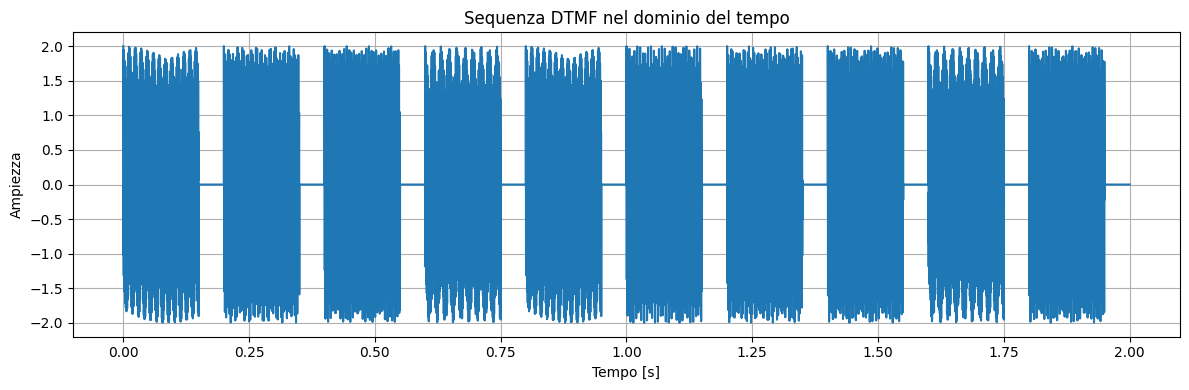

Audio salvato: Audio/sequences/sequenza_pause.wav
Plot salvato in: Plots/DTMF_implementation/spettro_sequenza_pause.pdf


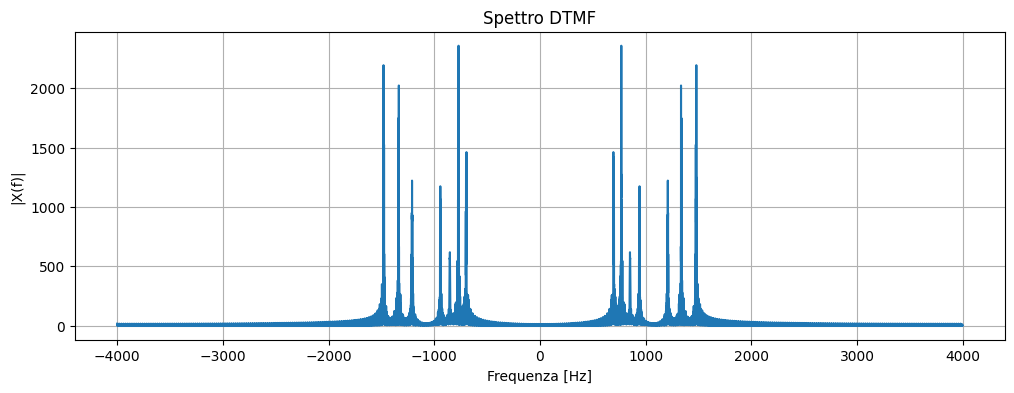

Sequenza originale:    ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']
Sequenza riconosciuta: ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']
Riconoscimento corretto!


In [8]:
# Generazione sequenza con pause
pauseDuration = 0.05
full_signal_pauses = dialNumber_pauses(sequenza, toneDuration, Fs, pauseDuration)

# Visualizzazione e salvataggio nel dominio del tempo
plot_and_save_sequence(
    full_signal_pauses, 
    Fs, 
    filename="sequenza_pause.wav",
    plot_filename="sequenza_pause.pdf",
    plot_folder=PLOTS_IMPLEMENTATION,
    audio_folder=AUDIO_SEQUENCES
)

# Visualizzazione e salvataggio dello spettro
plot_spectrum(
    full_signal_pauses, 
    Fs, 
    plot_filename="spettro_sequenza_pause.pdf",
    plot_folder=PLOTS_IMPLEMENTATION
)

# Riconoscimento sequenza con pause
detected_pauses = detect_sequence_pauses(
    full_signal_pauses, 
    toneDuration, 
    pauseDuration, 
    Fs, 
    silence_threshold=0.05
)

print(f"Sequenza originale:    {list(sequenza)}")
print(f"Sequenza riconosciuta: {detected_pauses}")

# Verifica correttezza
if detected_pauses == list(sequenza):
    print("Riconoscimento corretto!")
else:
    print("Errore nel riconoscimento")

#### **Confronto spettri: con e senza pause**

Plot salvato: Plots/DTMF_implementation/spettro_overlay_pause.pdf


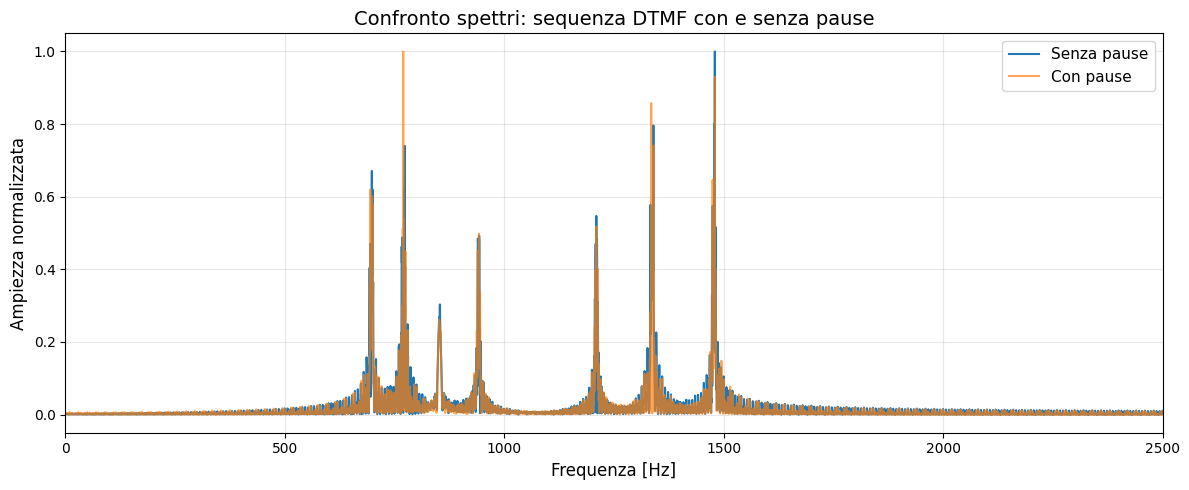

In [9]:
# Lunghezze originali
N_no = len(full_signal)
N_pa = len(full_signal_pauses)

# Lunghezza massima
N = max(N_no, N_pa)

# Padding per allineare le lunghezze
sig_no = np.pad(full_signal, (0, N - N_no), mode='constant')
sig_pa = np.pad(full_signal_pauses, (0, N - N_pa), mode='constant')

# FFT
X_no = fftshift(fft(sig_no))
X_pa = fftshift(fft(sig_pa))

# Ampiezze normalizzate
X_no_norm = np.abs(X_no) / np.max(np.abs(X_no))
X_pa_norm = np.abs(X_pa) / np.max(np.abs(X_pa))

# Asse delle frequenze
freqs = np.linspace(-Fs/2, Fs/2, N, endpoint=False)

# Plot overlay
plt.figure(figsize=(12, 5))
plt.plot(freqs, X_no_norm, label="Senza pause", linewidth=1.5)
plt.plot(freqs, X_pa_norm, label="Con pause", alpha=0.7, linewidth=1.5)
plt.xlim(0, 2500)
plt.xlabel("Frequenza [Hz]", fontsize=12)
plt.ylabel("Ampiezza normalizzata", fontsize=12)
plt.title("Confronto spettri: sequenza DTMF con e senza pause", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Salvataggio
os.makedirs(PLOTS_IMPLEMENTATION, exist_ok=True)
plot_path = os.path.join(PLOTS_IMPLEMENTATION, "spettro_overlay_pause.pdf")
plt.tight_layout()
plt.savefig(plot_path, format='pdf', bbox_inches='tight')
print(f"Plot salvato: {plot_path}")

plt.show()
plt.close()

## **2. Esperimenti e metodologia**

In [10]:
np.random.seed(42)

### **2.1 Variazione della durata del tono**

In [11]:
durations = np.round(np.logspace(np.log10(0.001), np.log10(0.2), 12), 4).tolist()


Visualizzazione effetto durata su segnale e spettro...
Grafico salvato: Plots/experiments/duration/single_tone_durations_comparison.pdf


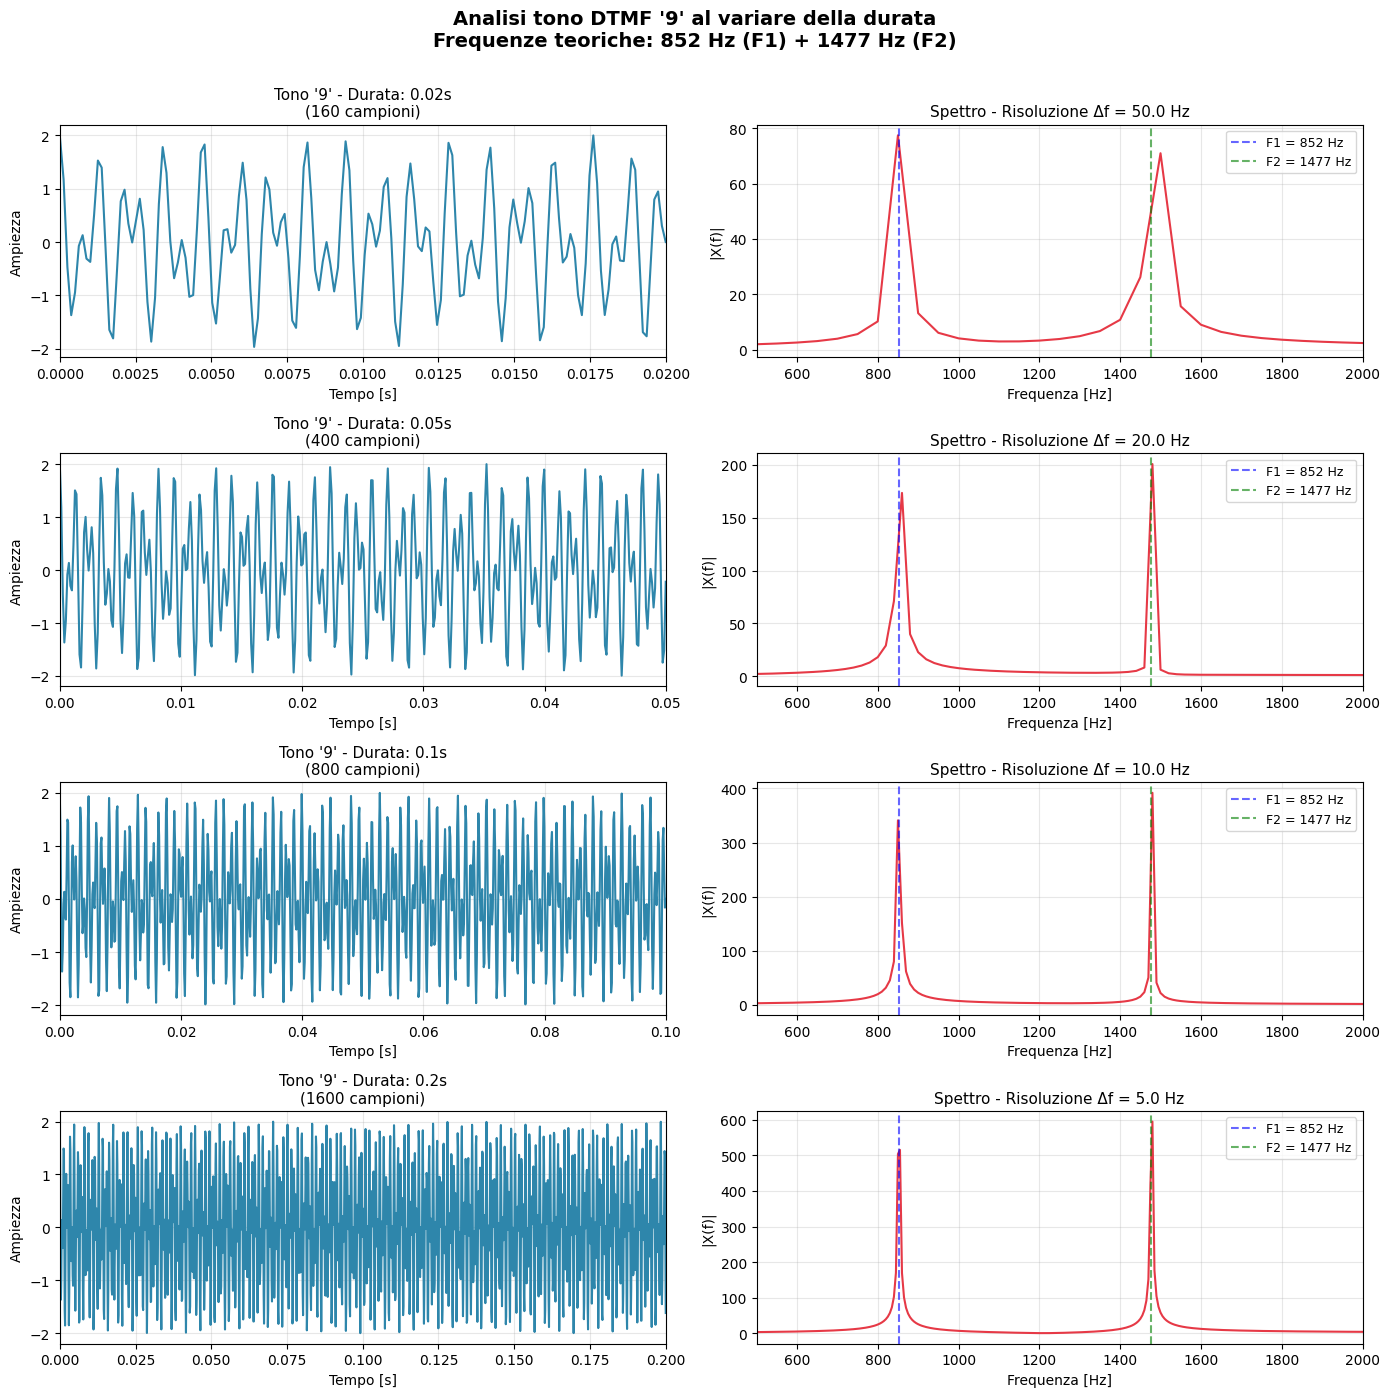

Grafico salvato: Plots/experiments/duration/sequence_durations_comparison.pdf


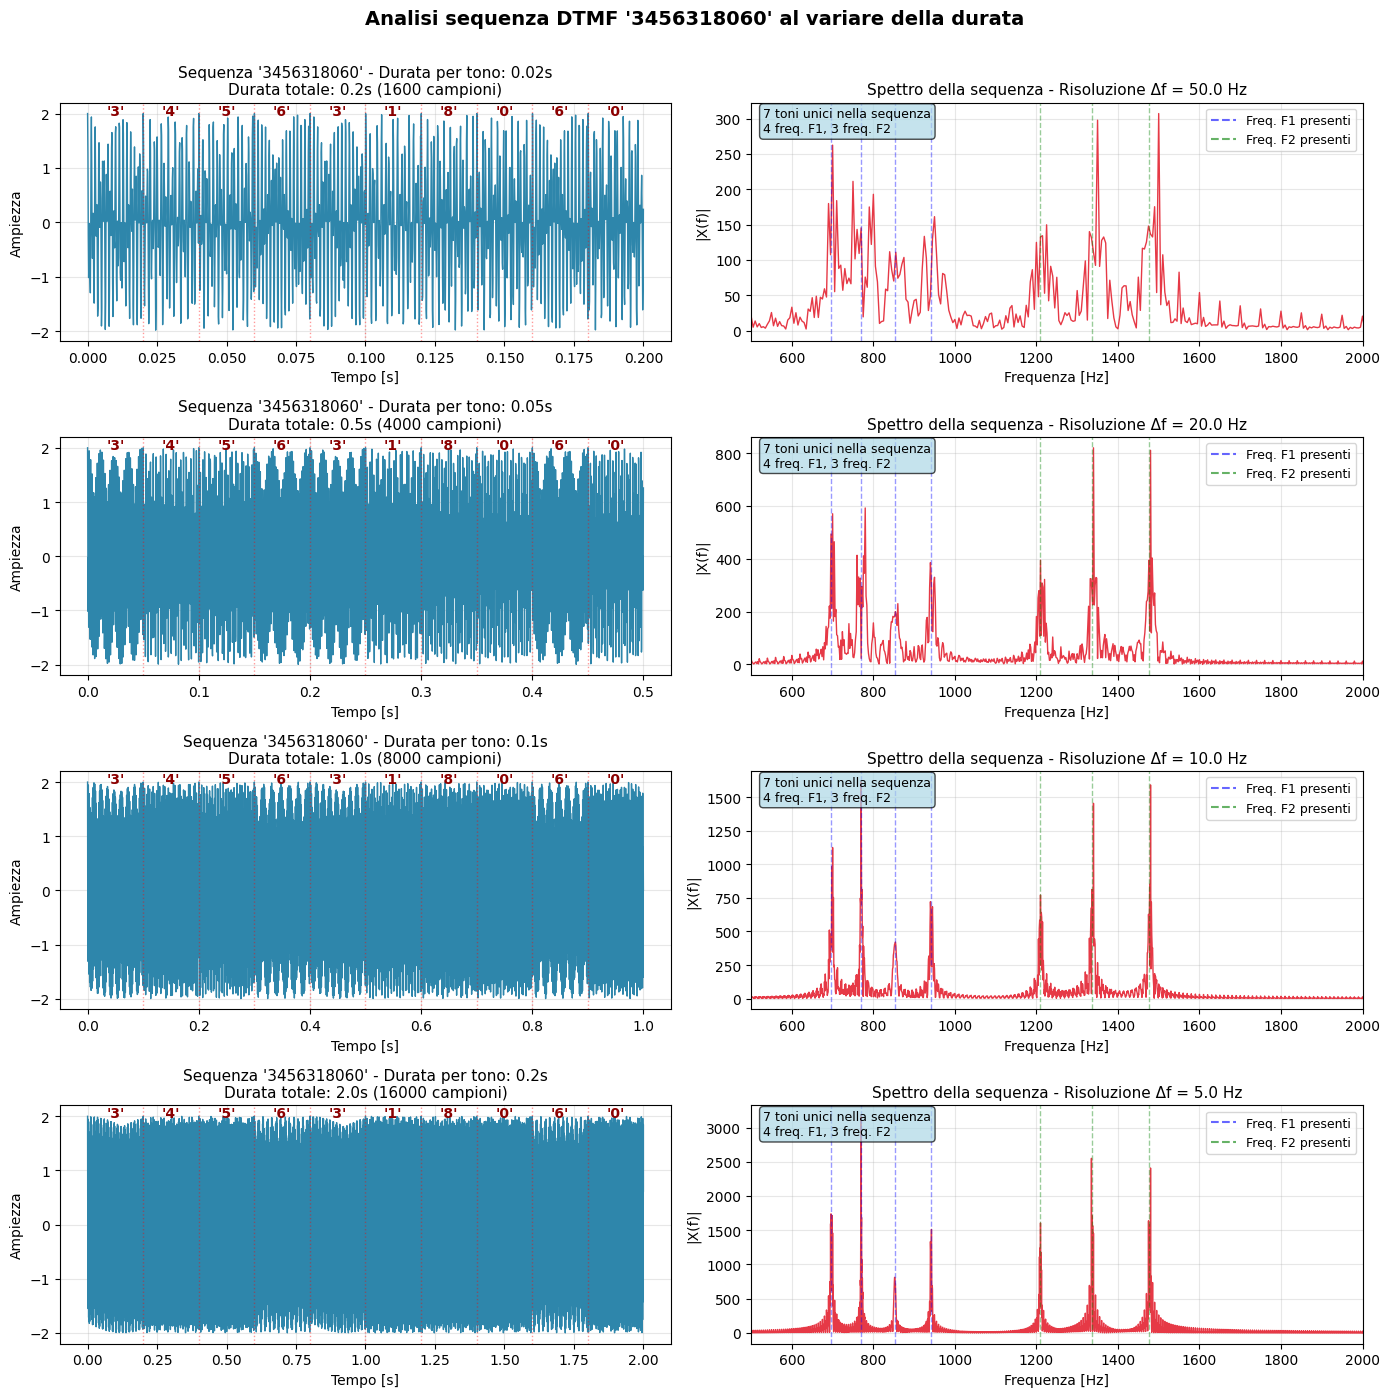

ESPERIMENTI: VARIAZIONE DELLA DURATA DEL TONO
PARTE 1: TEST SU SINGOLI TONI

Test durata: 0.001s (n_trials=50 per tono)

Accuratezza globale: 12.5% (100/800)

Toni con errori:
  '2': 0.0% (0/50)
  '3': 0.0% (0/50)
  '4': 0.0% (0/50)
  '5': 0.0% (0/50)
  '6': 0.0% (0/50)
  '7': 0.0% (0/50)
  '8': 0.0% (0/50)
  '9': 0.0% (0/50)
  '0': 0.0% (0/50)
  '*': 0.0% (0/50)
  '#': 0.0% (0/50)
  'B': 0.0% (0/50)
  'C': 0.0% (0/50)
  'D': 0.0% (0/50)

Test durata: 0.0016s (n_trials=50 per tono)

Accuratezza globale: 6.2% (50/800)

Toni con errori:
  '2': 0.0% (0/50)
  '3': 0.0% (0/50)
  '4': 0.0% (0/50)
  '5': 0.0% (0/50)
  '6': 0.0% (0/50)
  '7': 0.0% (0/50)
  '8': 0.0% (0/50)
  '9': 0.0% (0/50)
  '0': 0.0% (0/50)
  '*': 0.0% (0/50)
  '#': 0.0% (0/50)
  'A': 0.0% (0/50)
  'B': 0.0% (0/50)
  'C': 0.0% (0/50)
  'D': 0.0% (0/50)

Test durata: 0.0026s (n_trials=50 per tono)

Accuratezza globale: 12.5% (100/800)

Toni con errori:
  '2': 0.0% (0/50)
  '4': 0.0% (0/50)
  '5': 0.0% (0/50)
  '6': 0.0% (0/5

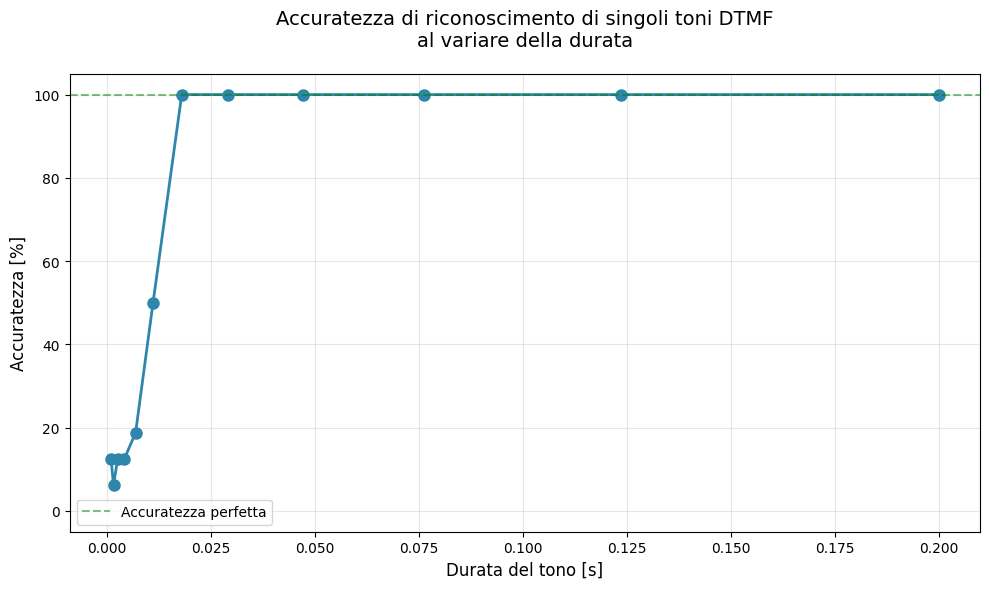

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.001s.pdf


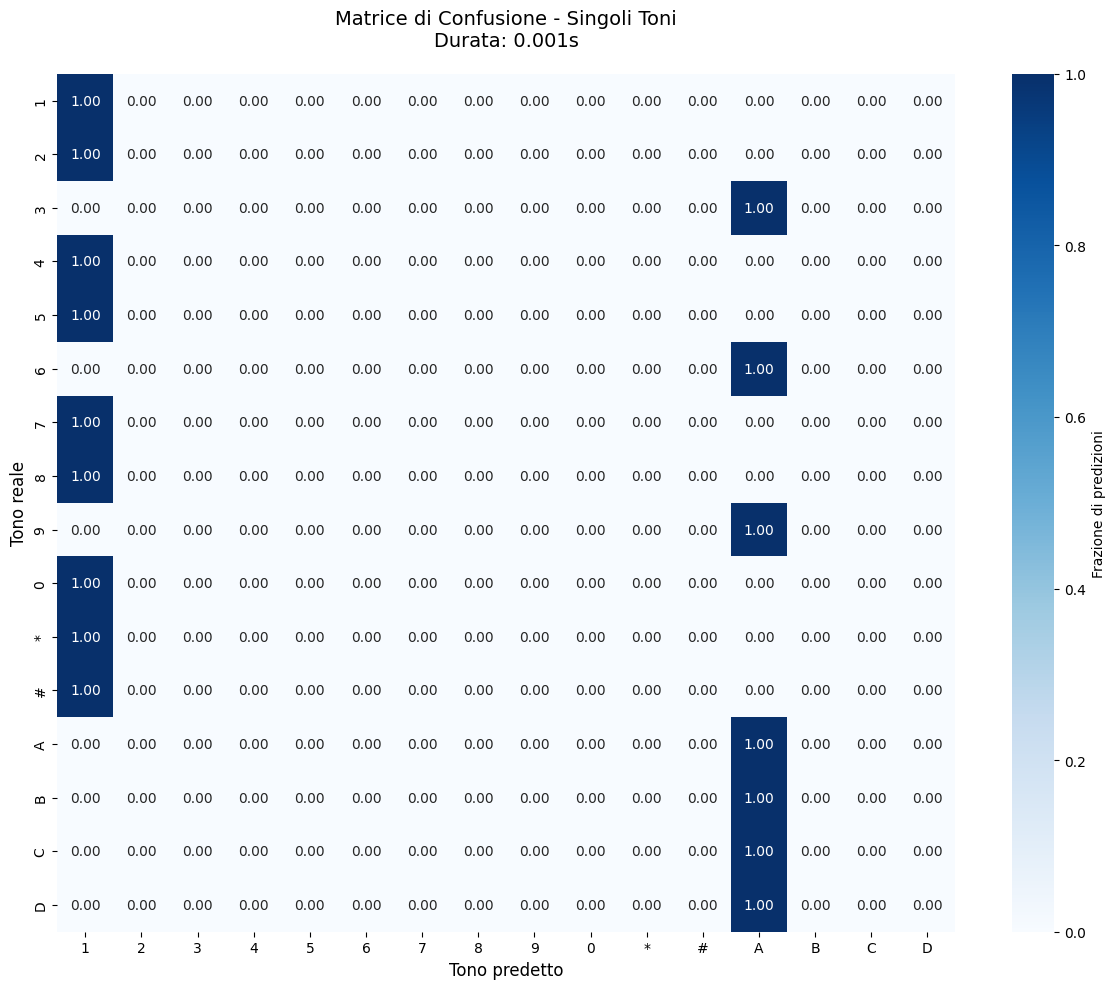

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.0016s.pdf


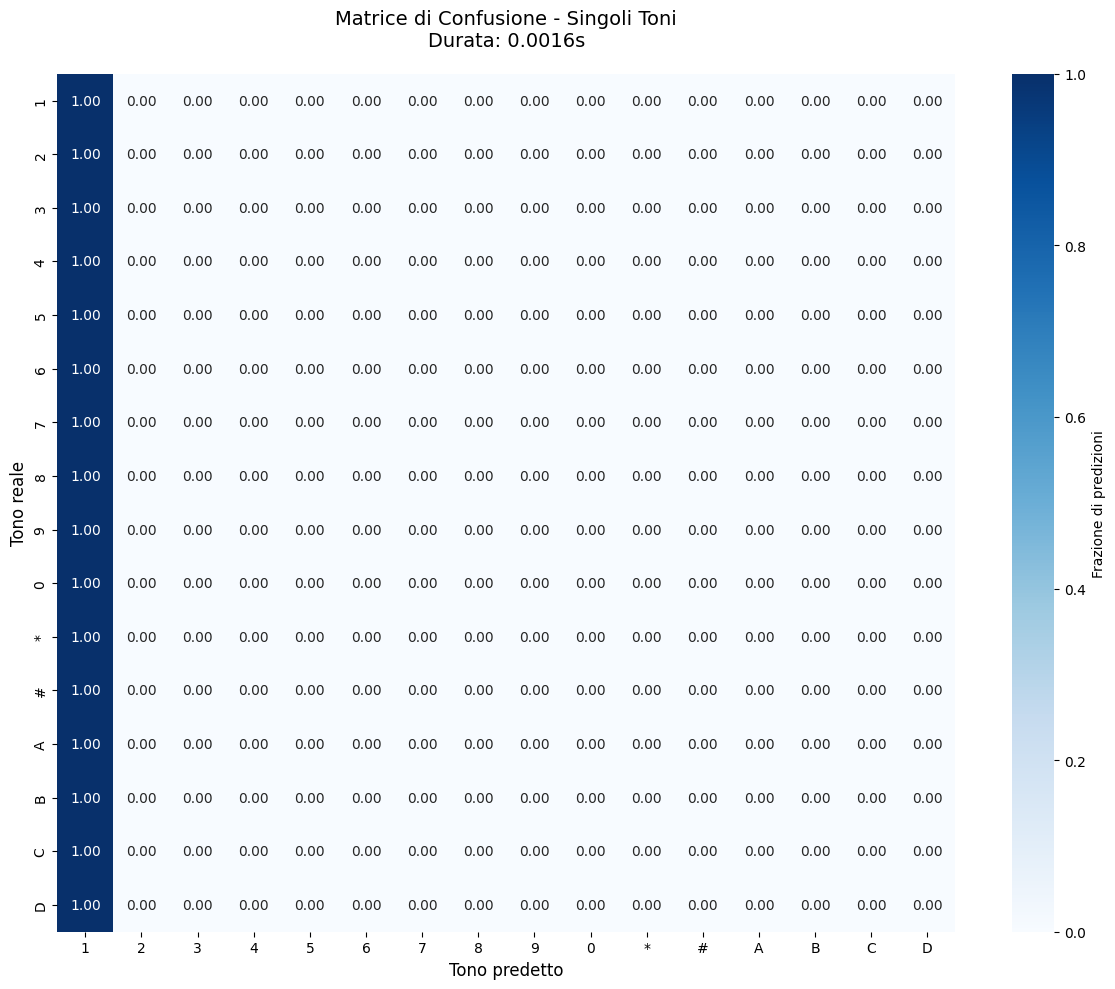

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.0026s.pdf


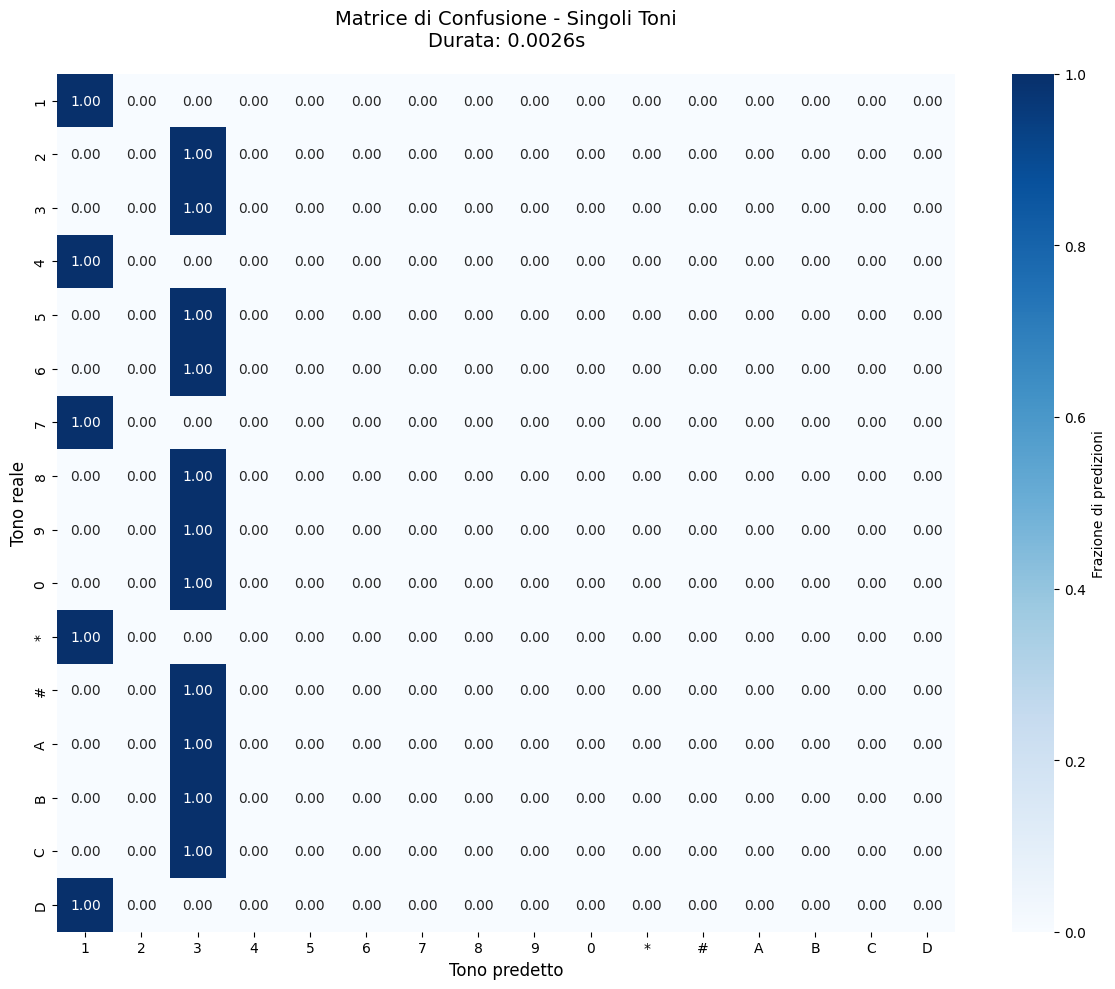

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.0042s.pdf


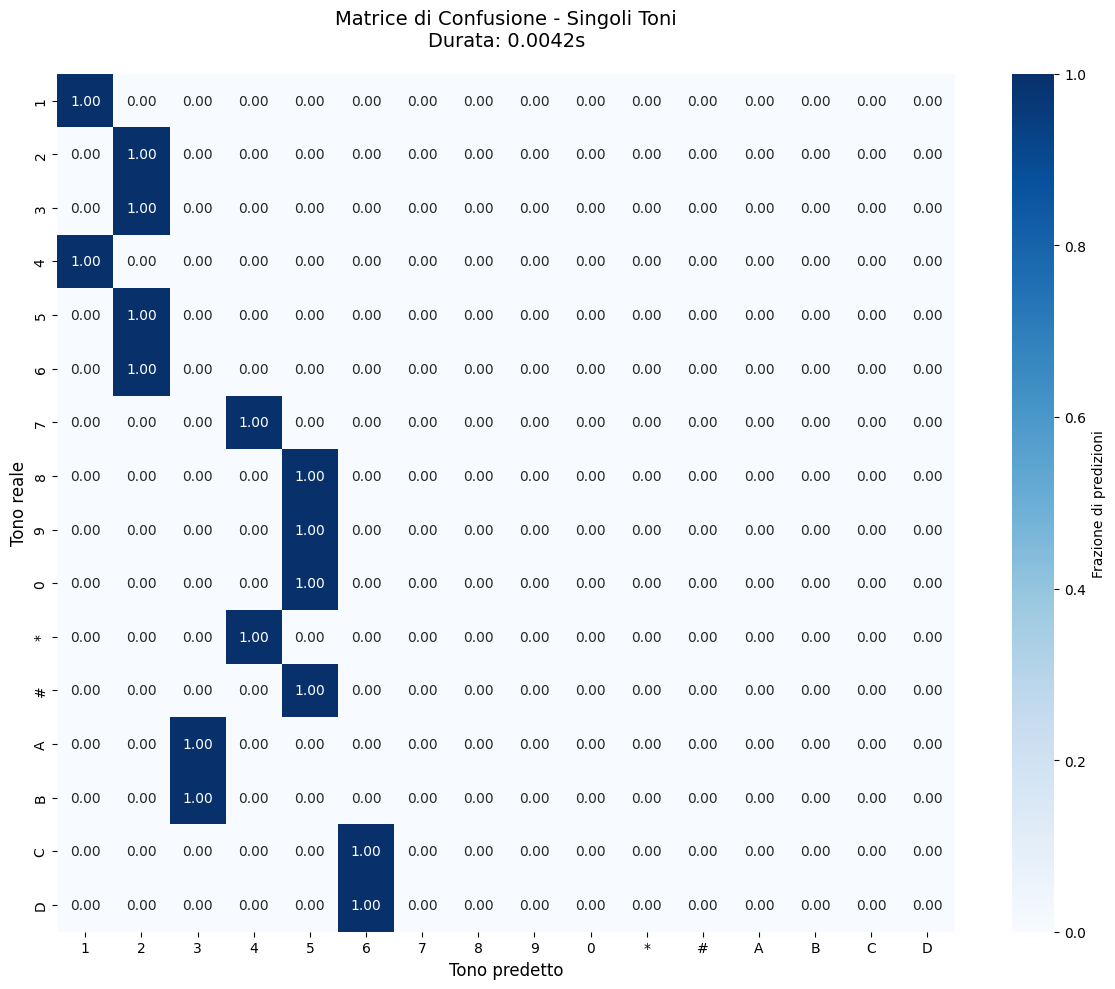

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.0069s.pdf


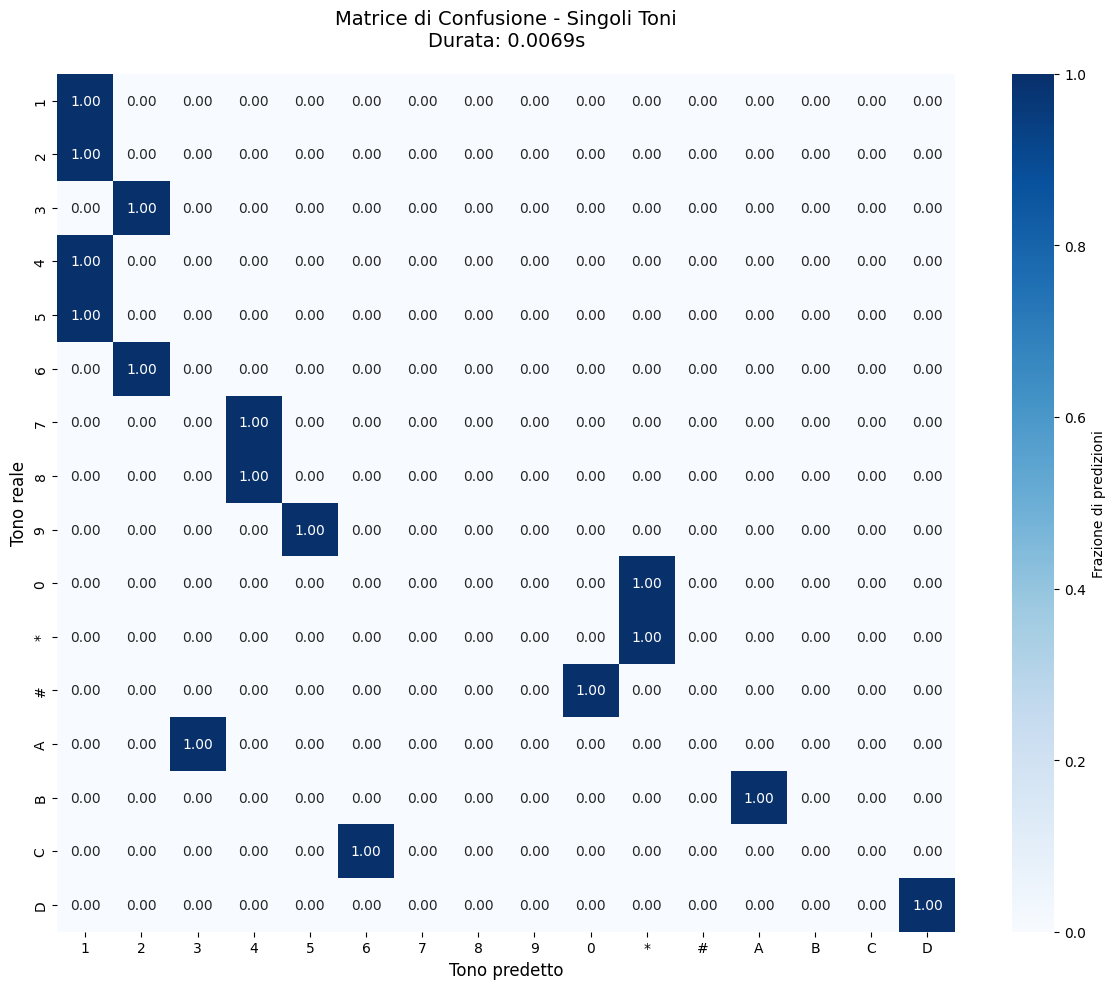

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.0111s.pdf


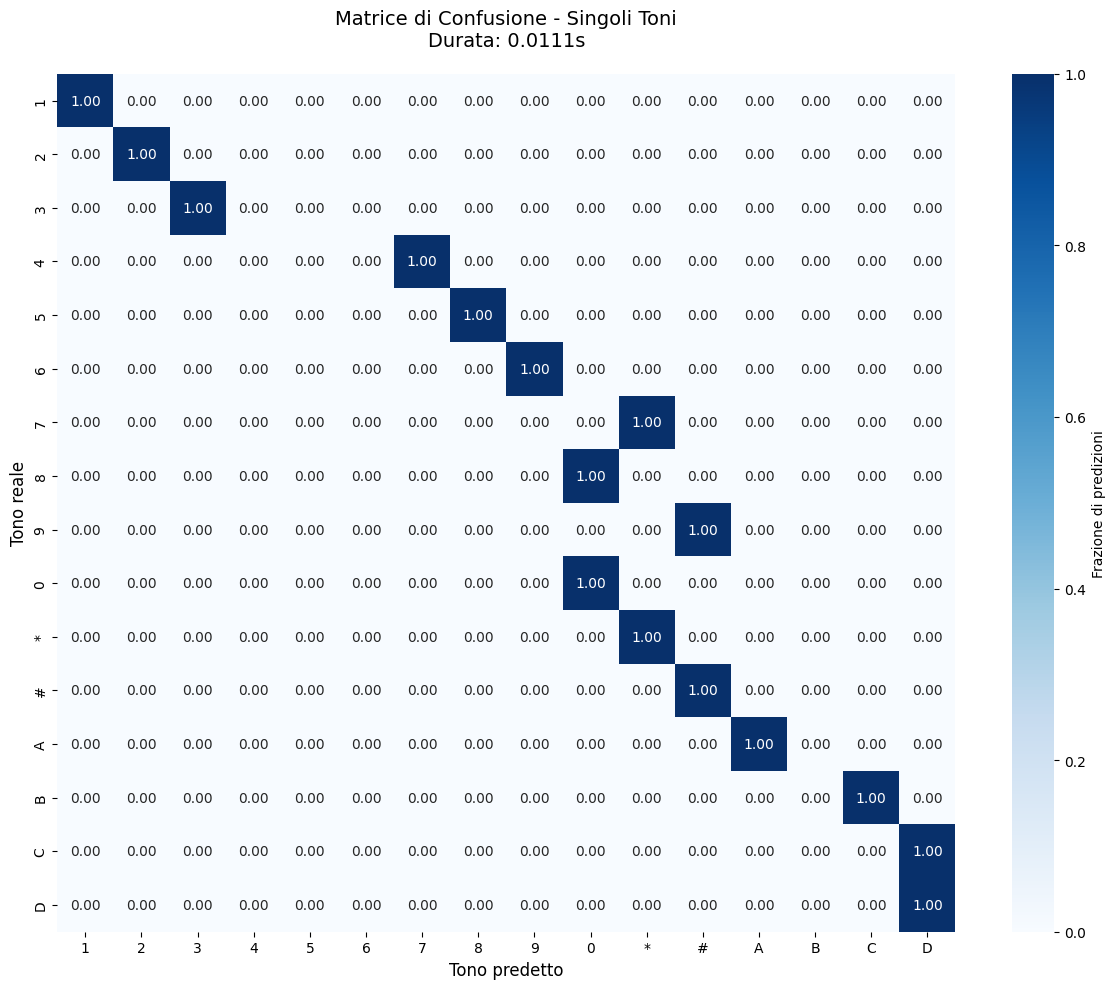

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.018s.pdf


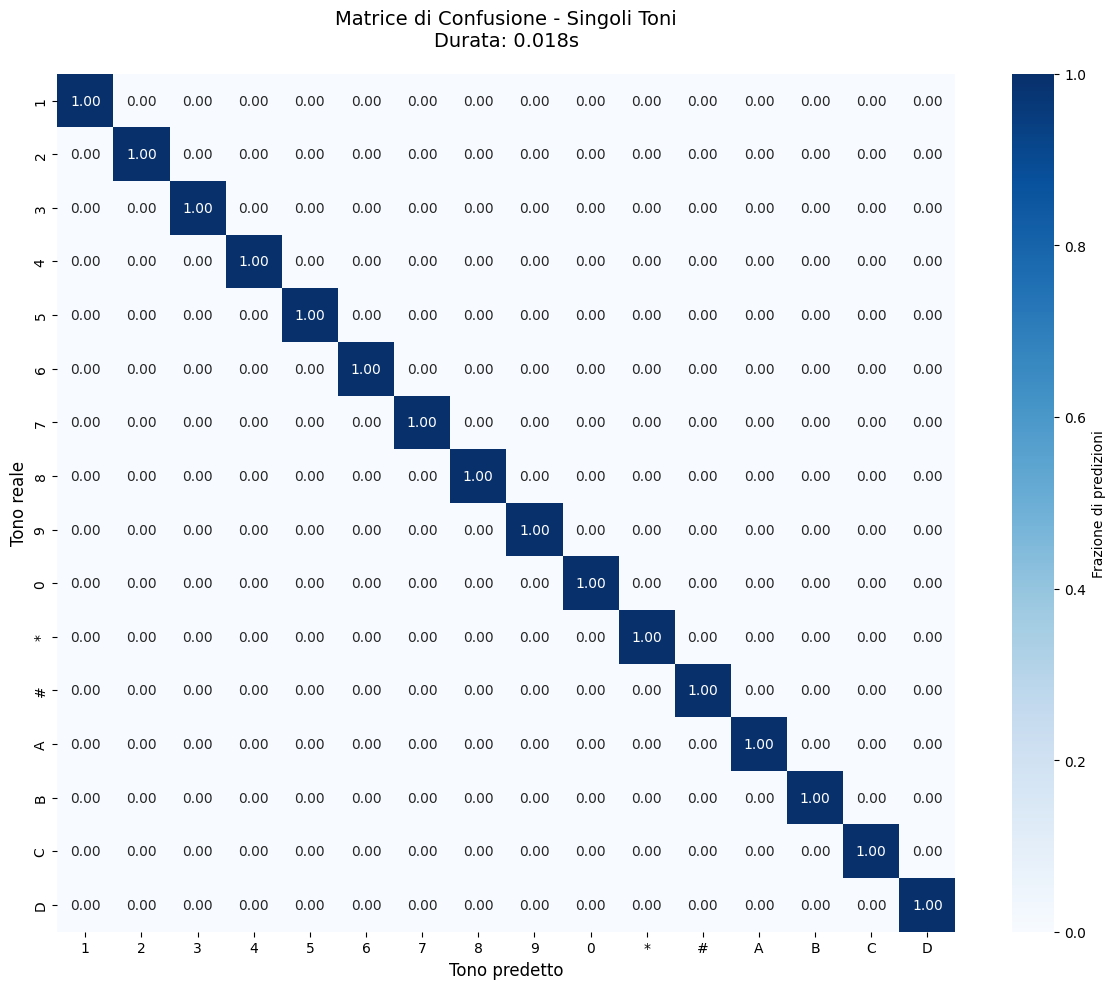

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.0291s.pdf


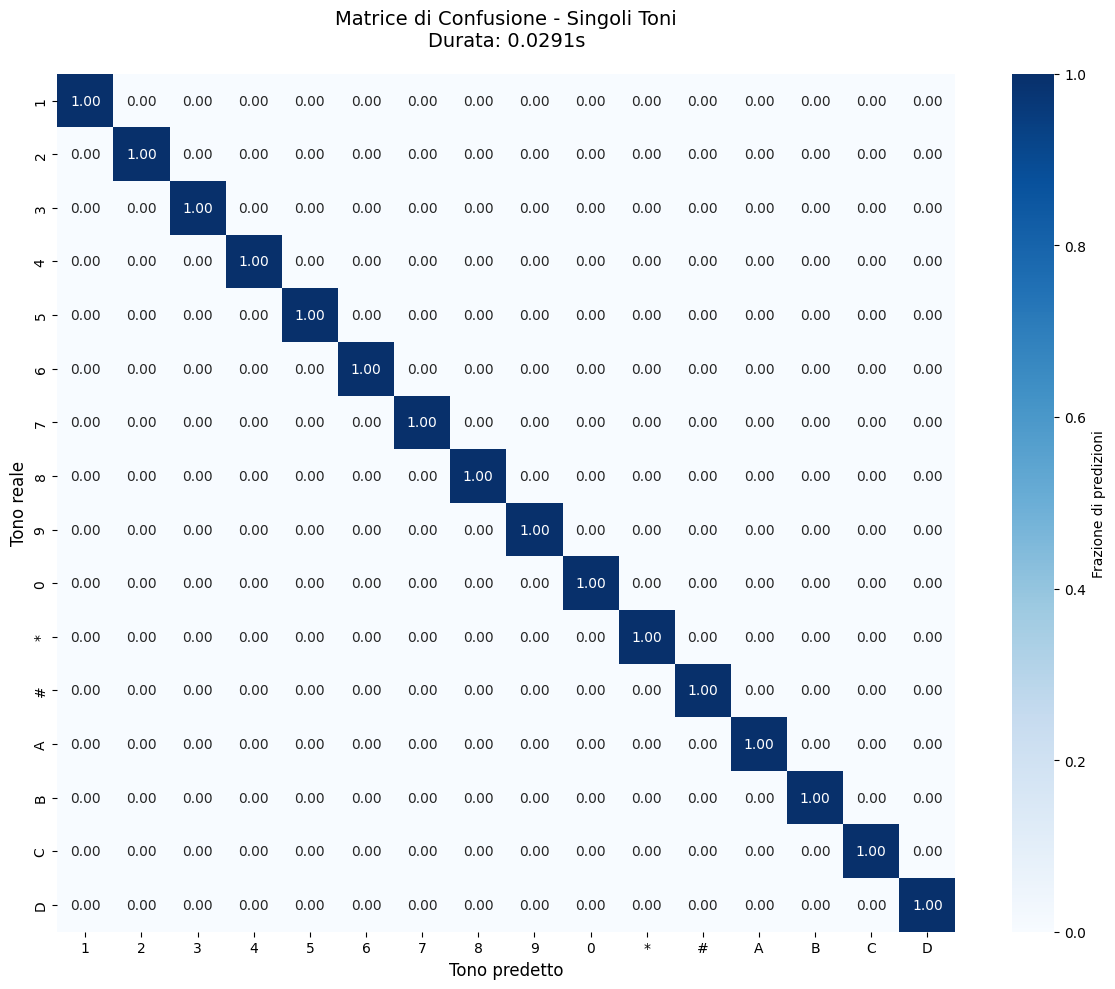

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.0471s.pdf


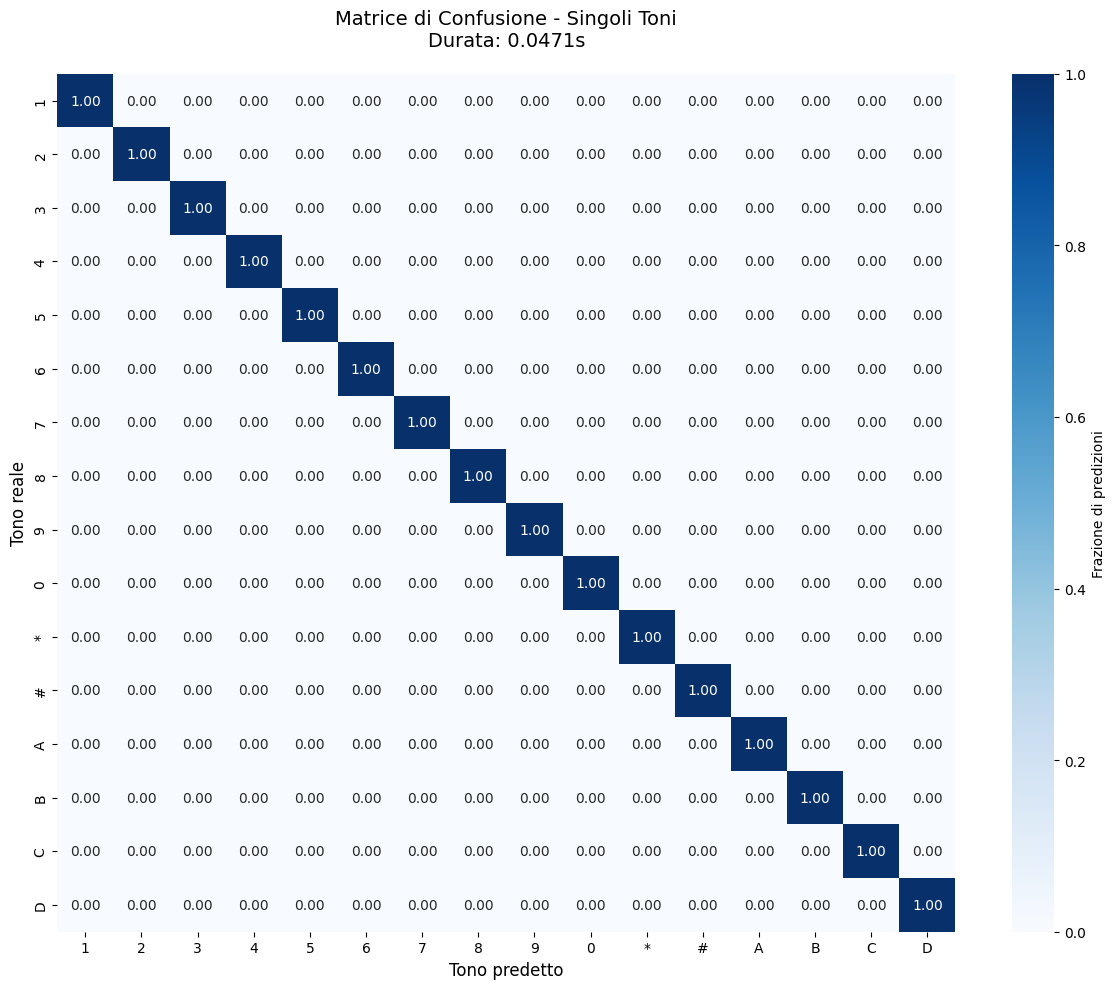

Grafico salvato: Plots/experiments/duration/confusion_matrix_single_0.0763s.pdf


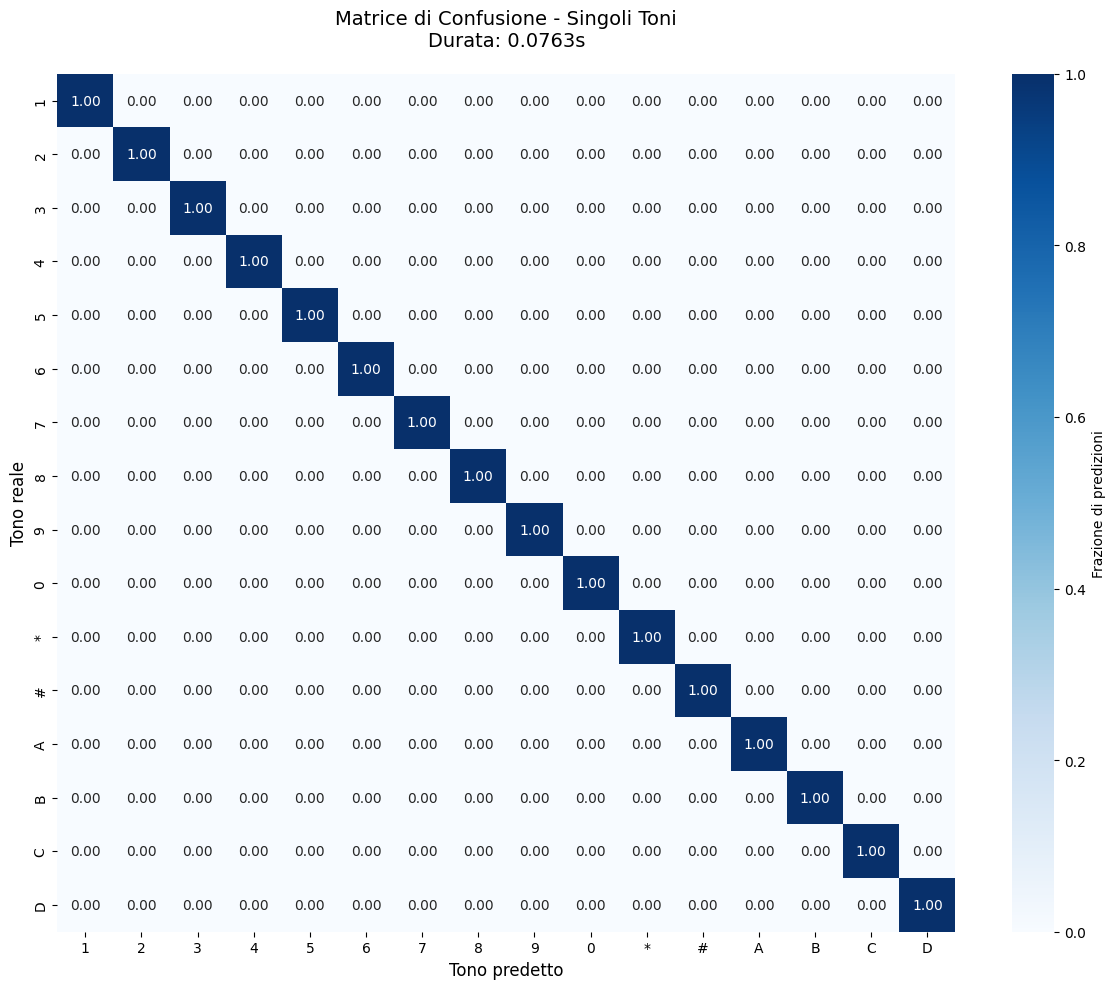


ANALISI ERRORI - Durata: 0.001s
Totale errori: 700/800 (87.5%)

Errori più frequenti:

  '2' → '1': 50 volta/e
Frequenze reali: 697 Hz, 1336 Hz
Frequenze predette: 697 Hz, 1209 Hz
Confusione nella frequenza ALTA (stessa riga)

  '3' → 'A': 50 volta/e
Frequenze reali: 697 Hz, 1477 Hz
Frequenze predette: 697 Hz, 1633 Hz
Confusione nella frequenza ALTA (stessa riga)

  '4' → '1': 50 volta/e
Frequenze reali: 770 Hz, 1209 Hz
Frequenze predette: 697 Hz, 1209 Hz
Confusione nella frequenza BASSA (stessa colonna)

  '5' → '1': 50 volta/e
Frequenze reali: 770 Hz, 1336 Hz
Frequenze predette: 697 Hz, 1209 Hz
Confusione totale (riga e colonna diverse)

  '6' → 'A': 50 volta/e
Frequenze reali: 770 Hz, 1477 Hz
Frequenze predette: 697 Hz, 1633 Hz
Confusione totale (riga e colonna diverse)

NOTA: Risoluzione spettrale Δf = 1/T = 1000.00 Hz
La distanza minima tra frequenze DTMF è:
  - F1: 73 Hz (es. 770-697 = 73 Hz)
  - F2: 127 Hz (es. 1336-1209 = 127 Hz)

La risoluzione di 1000 Hz è INSUFFICIENTE per


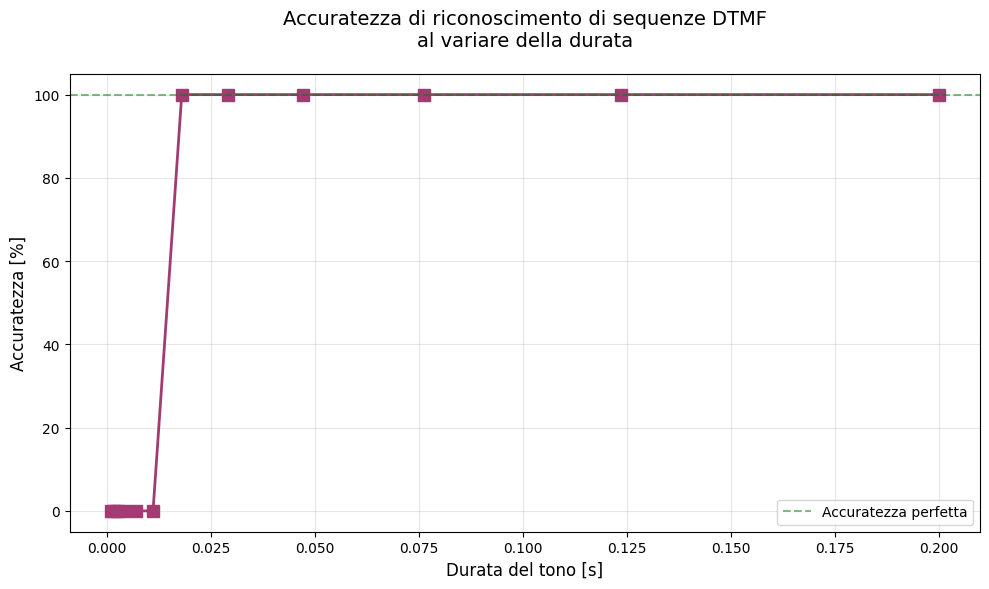

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.001s.pdf


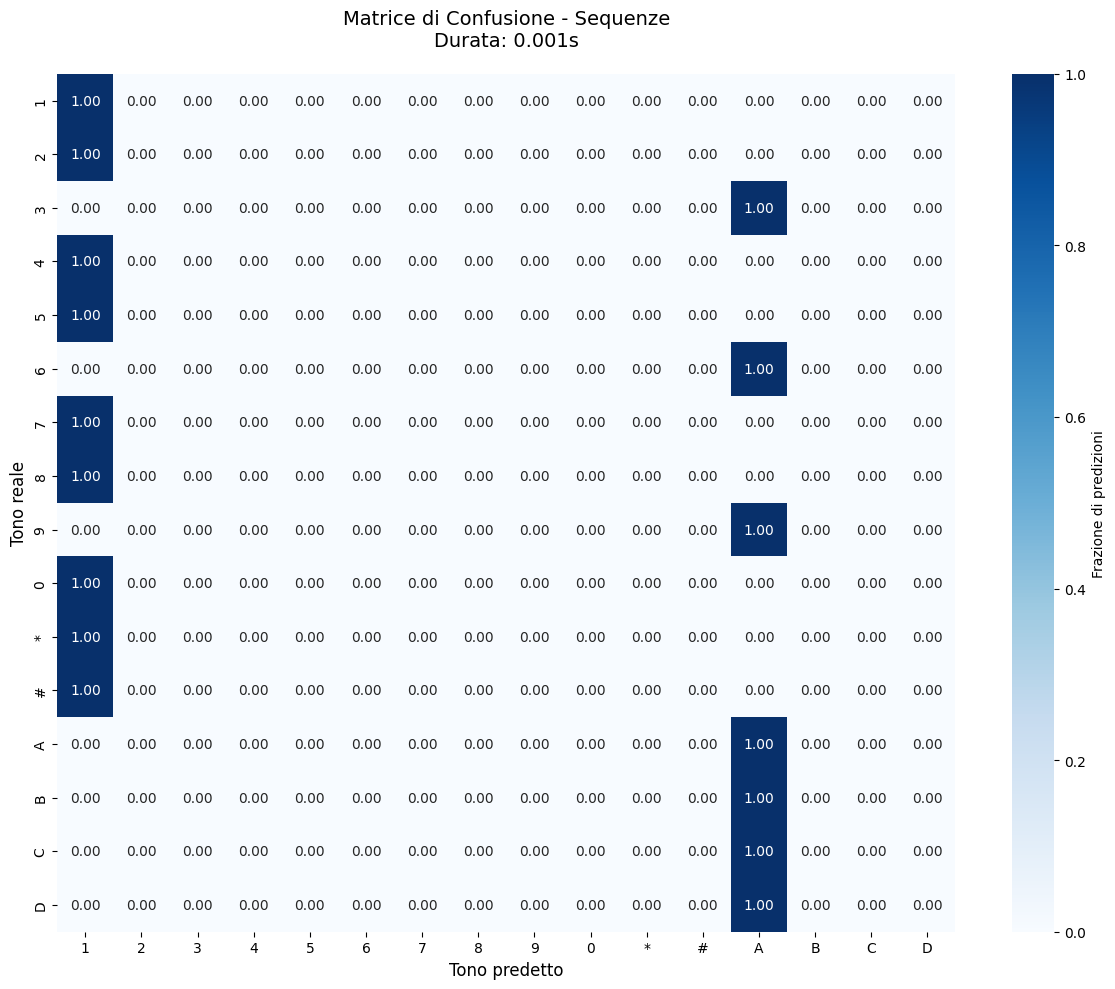

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.0016s.pdf


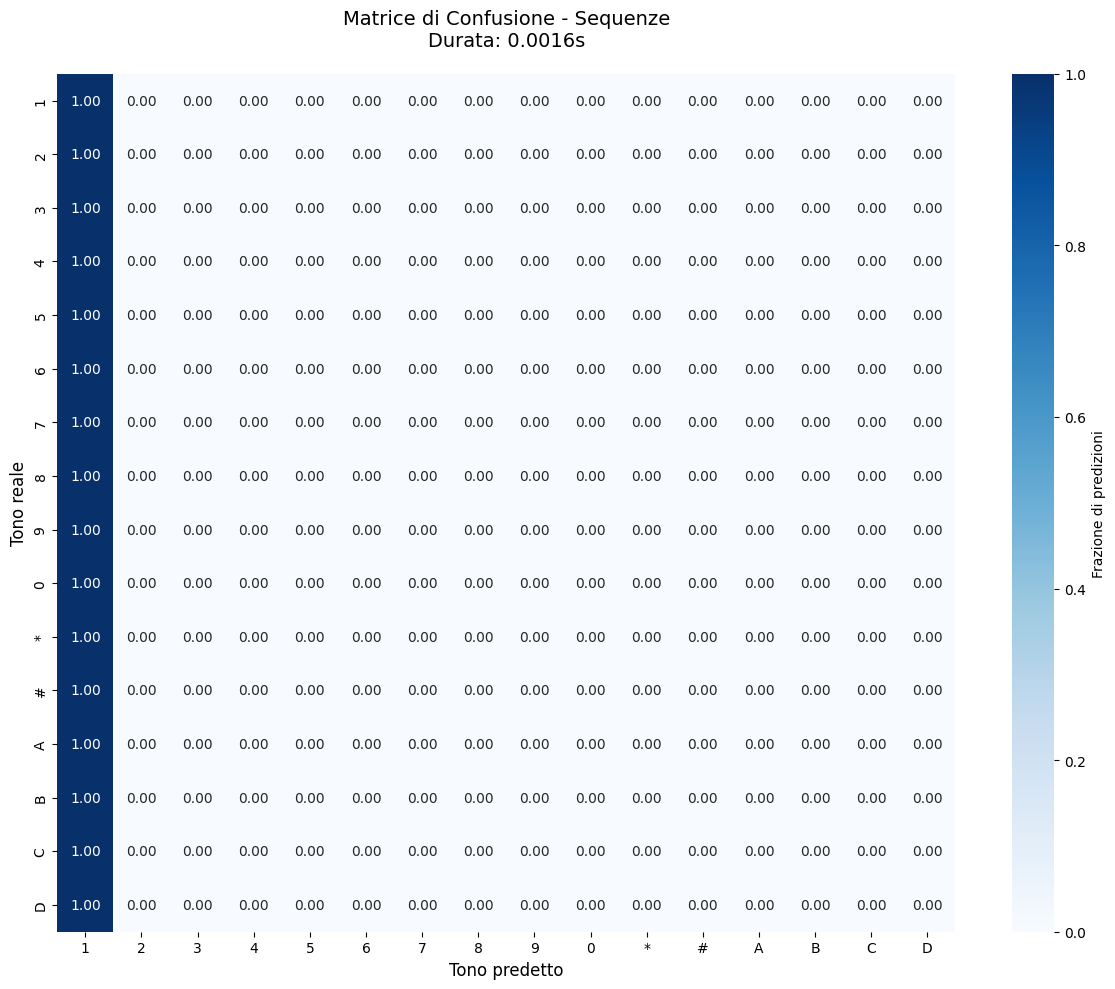

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.0026s.pdf


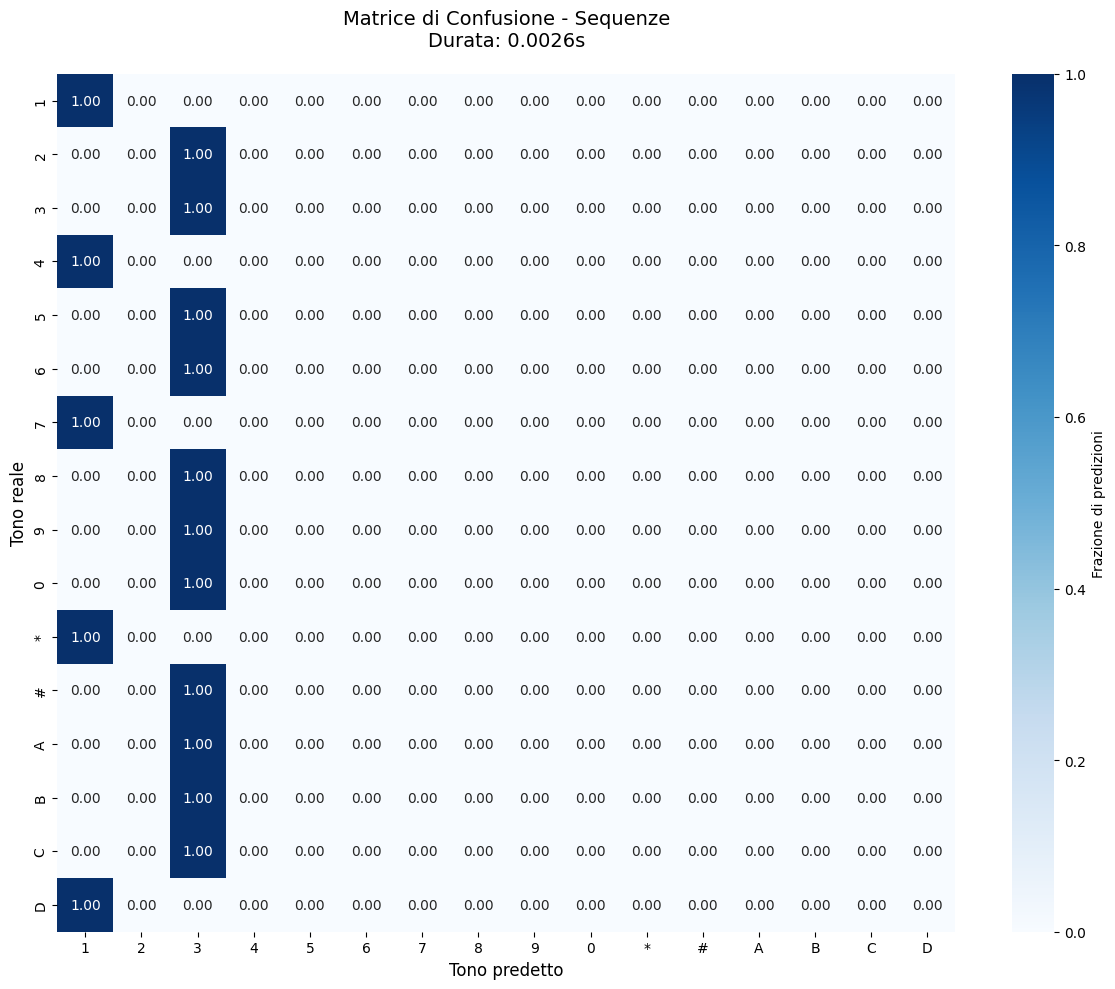

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.0042s.pdf


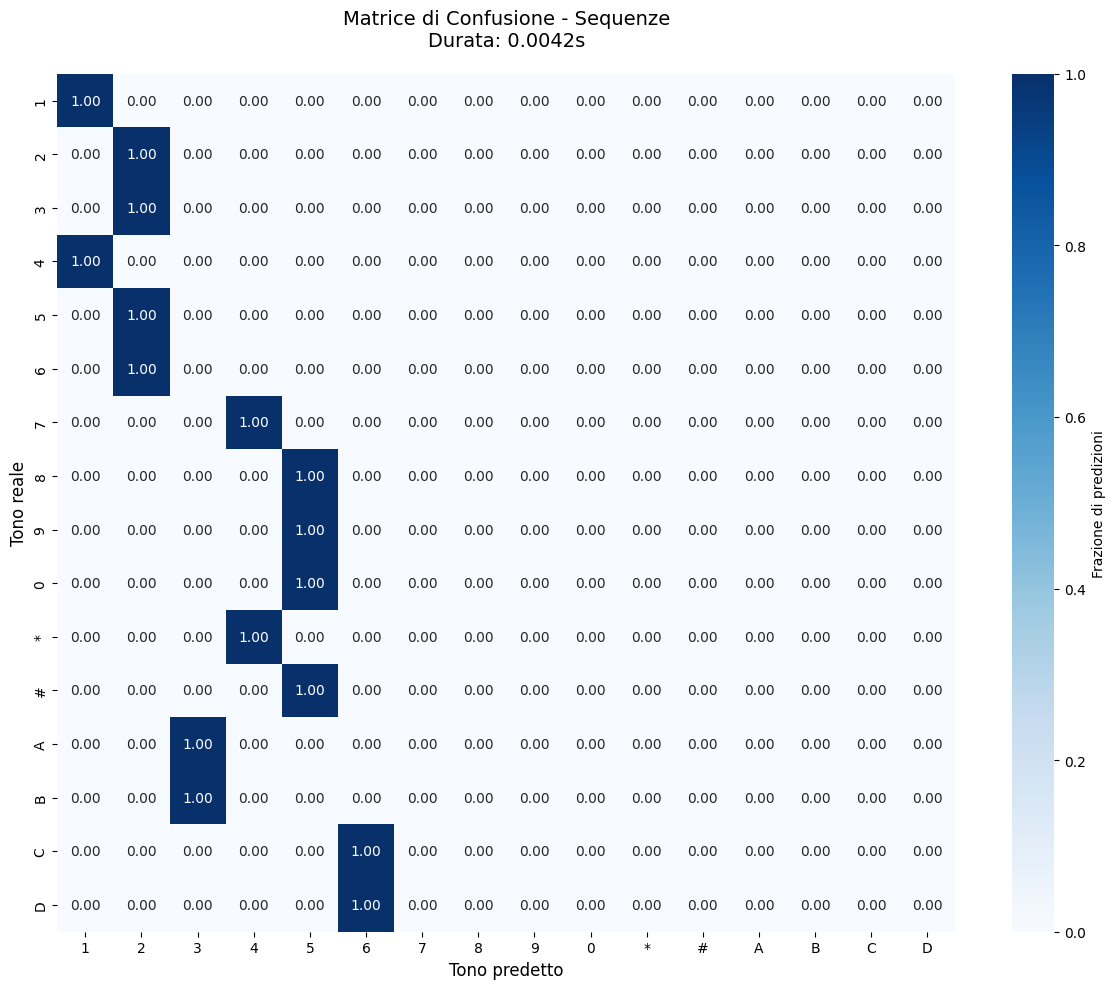

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.0069s.pdf


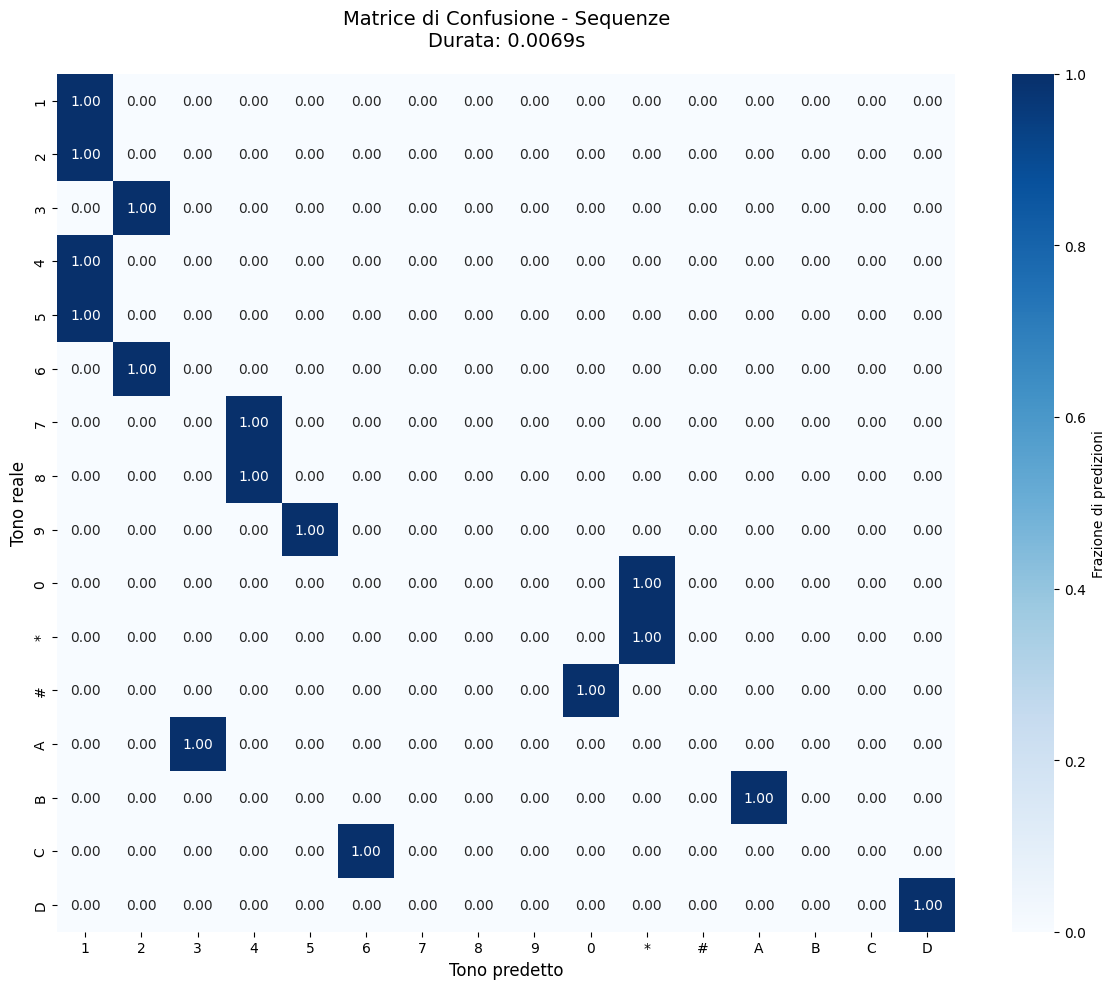

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.0111s.pdf


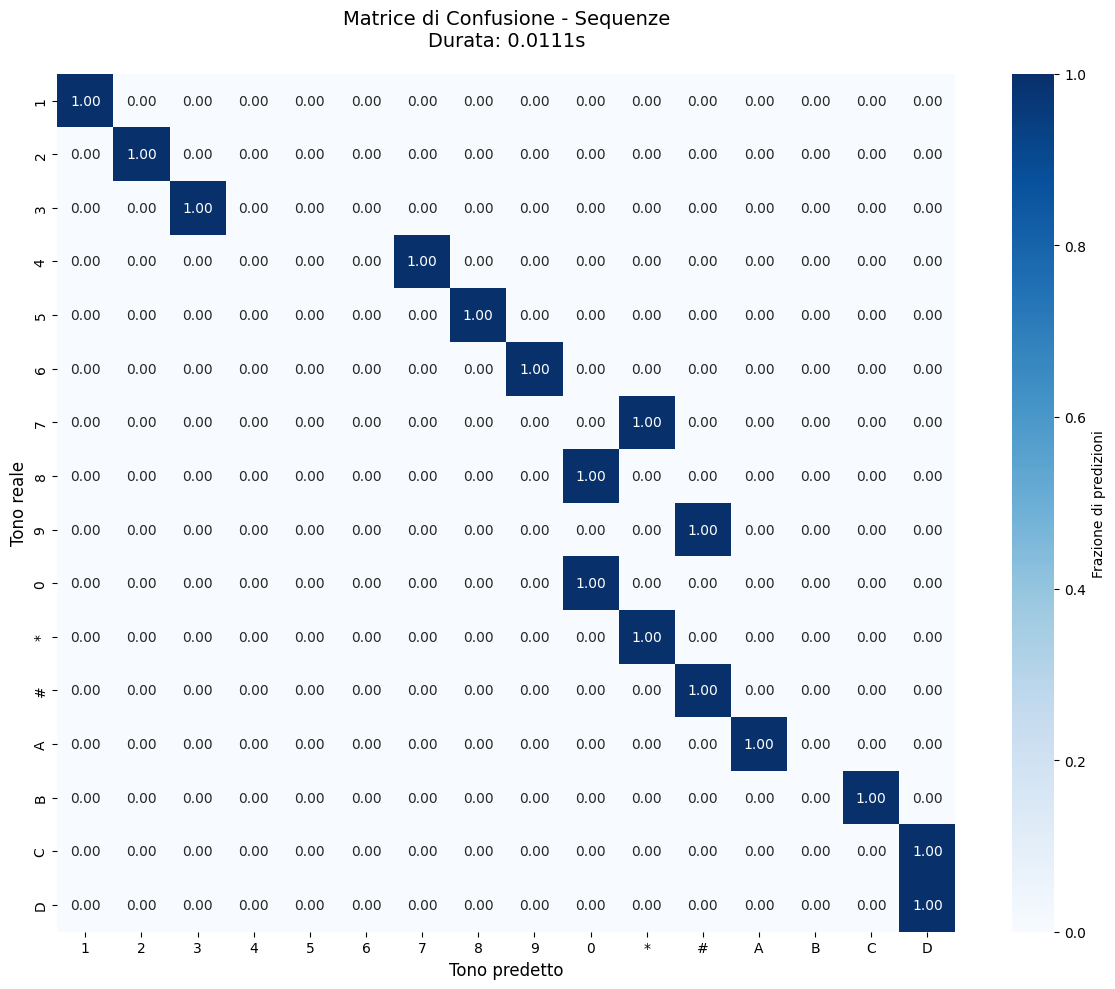

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.018s.pdf


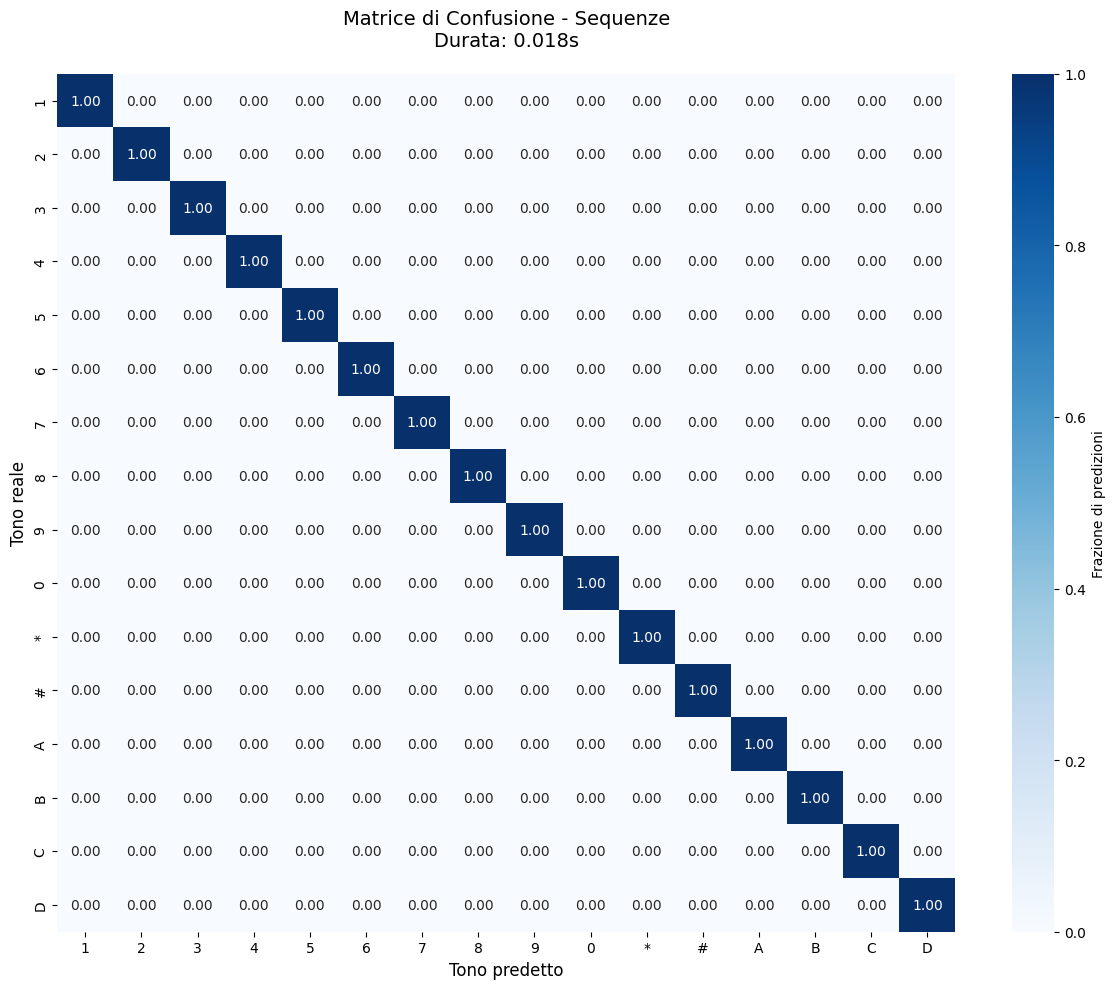

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.0291s.pdf


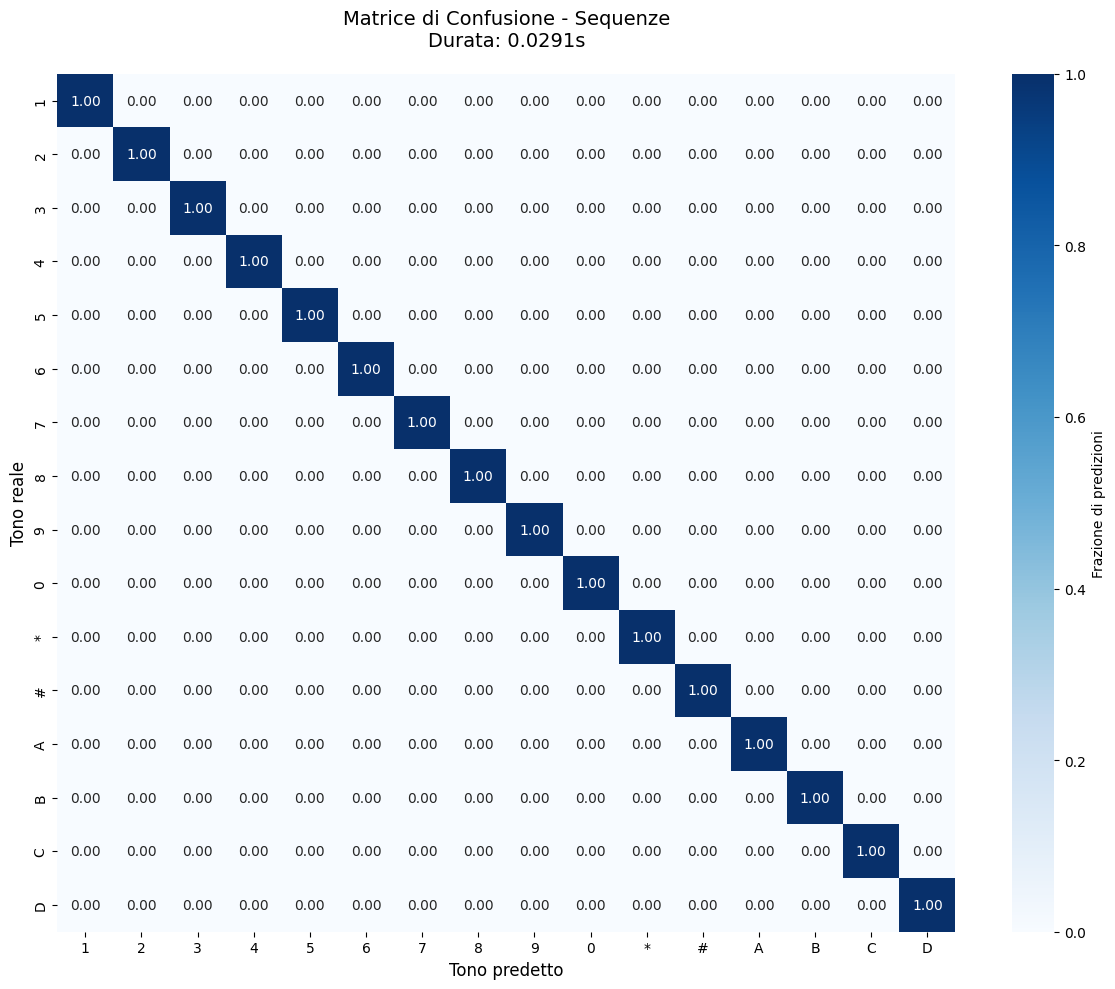

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.0471s.pdf


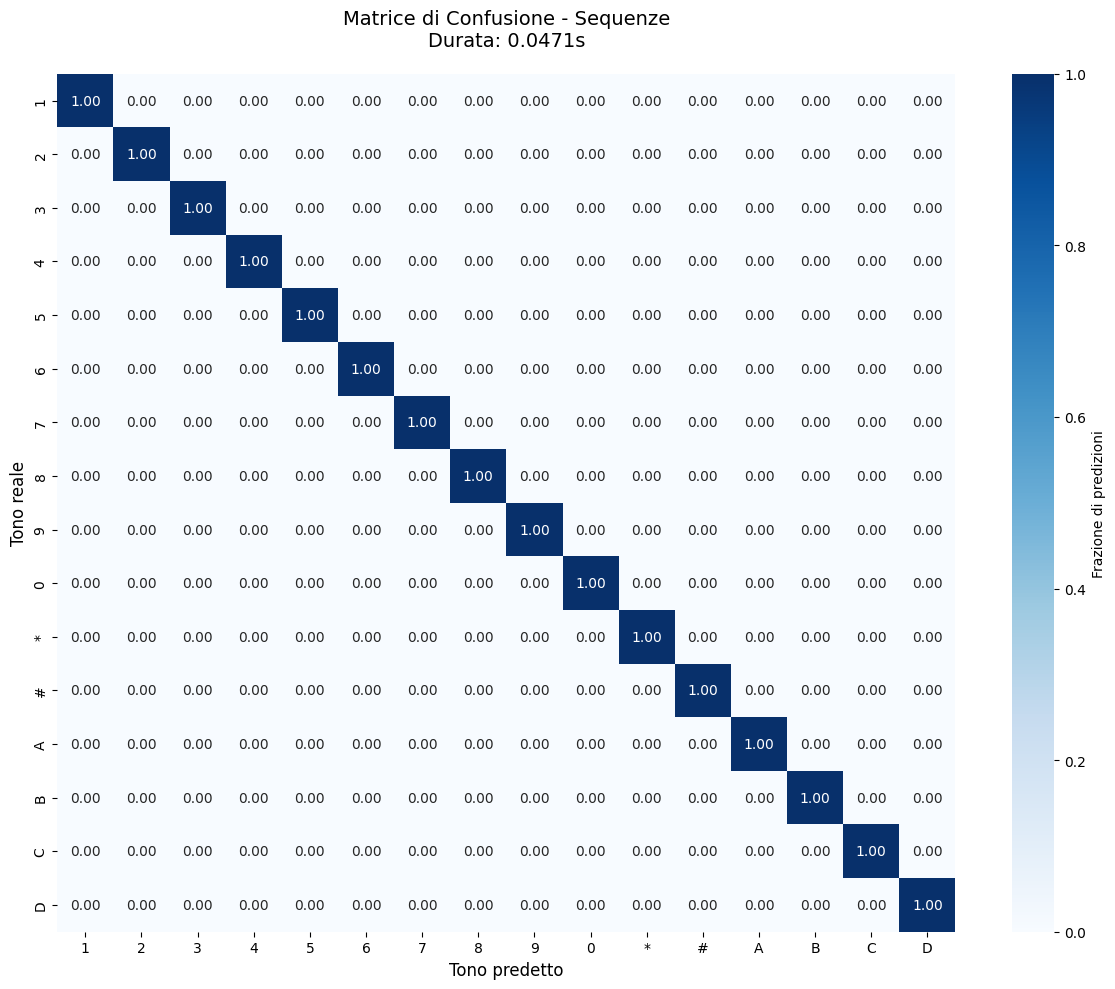

Grafico salvato: Plots/experiments/duration/confusion_matrix_sequences_0.0763s.pdf


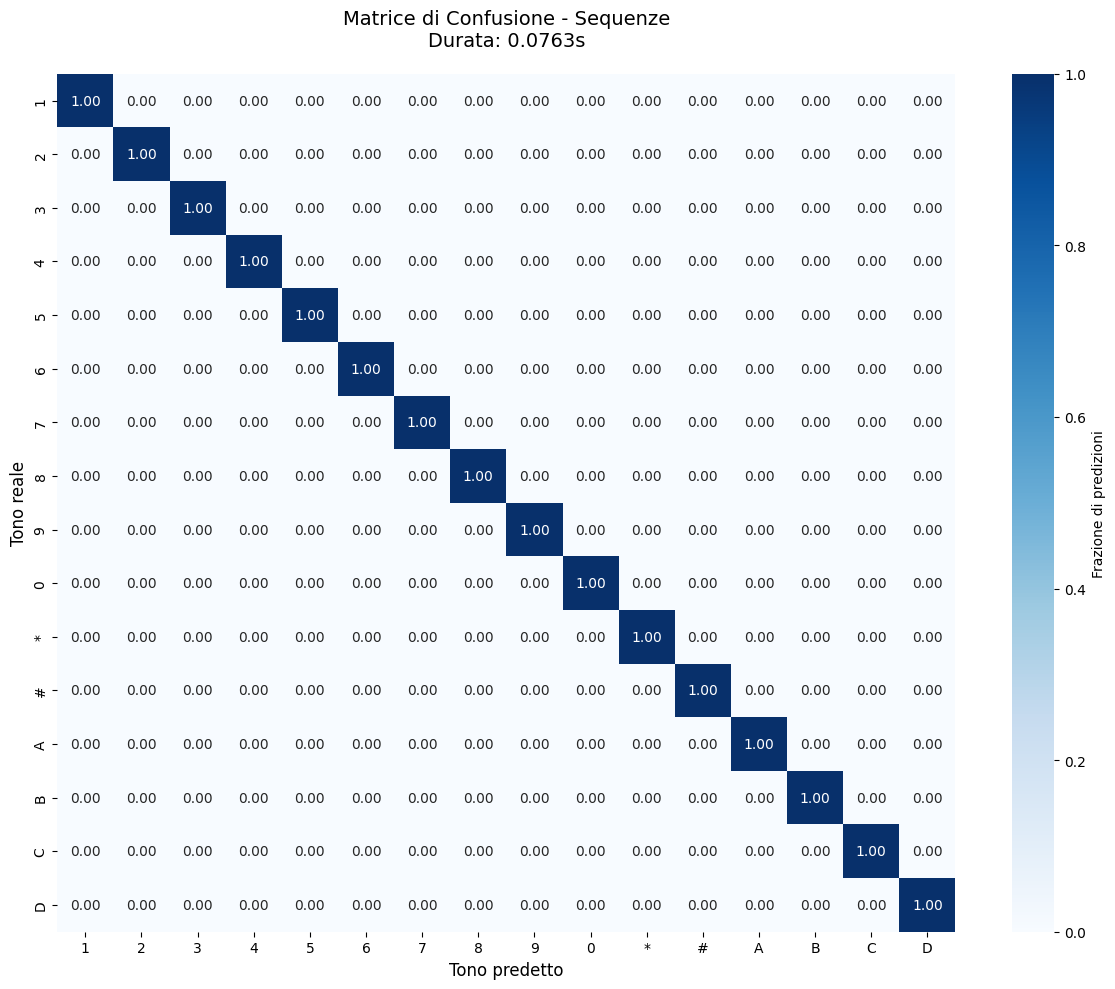


RIEPILOGO RISULTATI

Accuratezza singoli toni:
  0.001s: 12.5% (su 800 test)
  0.0016s: 6.2% (su 800 test)
  0.0026s: 12.5% (su 800 test)
  0.0042s: 12.5% (su 800 test)
  0.0069s: 18.8% (su 800 test)
  0.0111s: 50.0% (su 800 test)
  0.018s: 100.0% (su 800 test)
  0.0291s: 100.0% (su 800 test)
  0.0471s: 100.0% (su 800 test)
  0.0763s: 100.0% (su 800 test)
  0.1236s: 100.0% (su 800 test)
  0.2s: 100.0% (su 800 test)

Accuratezza sequenze:
  0.001s: 0.0%
  0.0016s: 0.0%
  0.0026s: 0.0%
  0.0042s: 0.0%
  0.0069s: 0.0%
  0.0111s: 0.0%
  0.018s: 100.0%
  0.0291s: 100.0%
  0.0471s: 100.0%
  0.0763s: 100.0%
  0.1236s: 100.0%
  0.2s: 100.0%

Tutti i risultati salvati in: Plots/experiments/duration/


In [12]:
# Esegui tutti gli esperimenti sulla durata
results_duration = run_duration_experiments(
    durations=durations,
    Fs=Fs,
    n_sequences=100,
    n_trials=50,
    tone_char='9',
    seq="3456318060",
    plot_folder=PLOTS_DURATION
)

### **2.2 Aggiunta di rumore al segnale**

ESPERIMENTI: EFFETTO DEL RUMORE

1. Generazione grafici tempo/frequenza...
Grafico salvato: Plots/experiments/noise/signal_noise_comparison.pdf


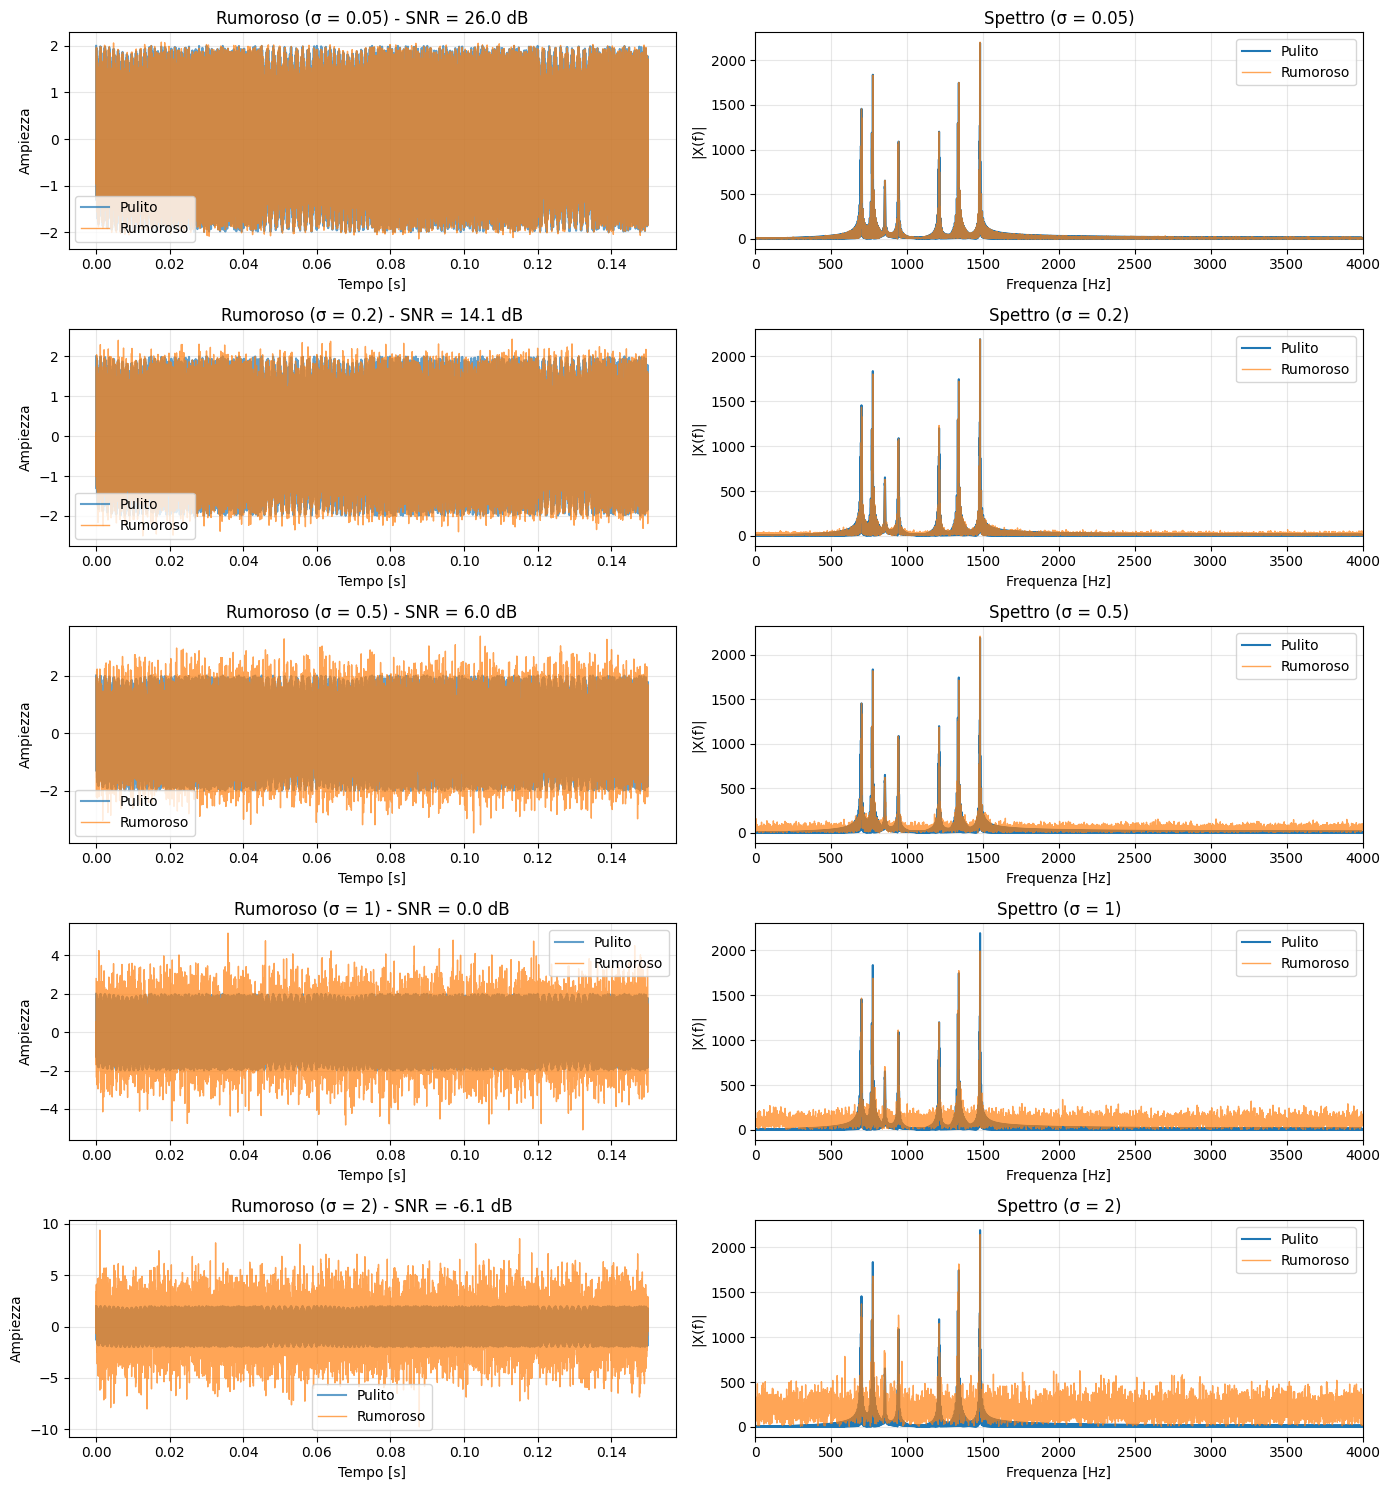

Grafico zoom salvato: Plots/experiments/noise/noise_zoom_temporal.pdf


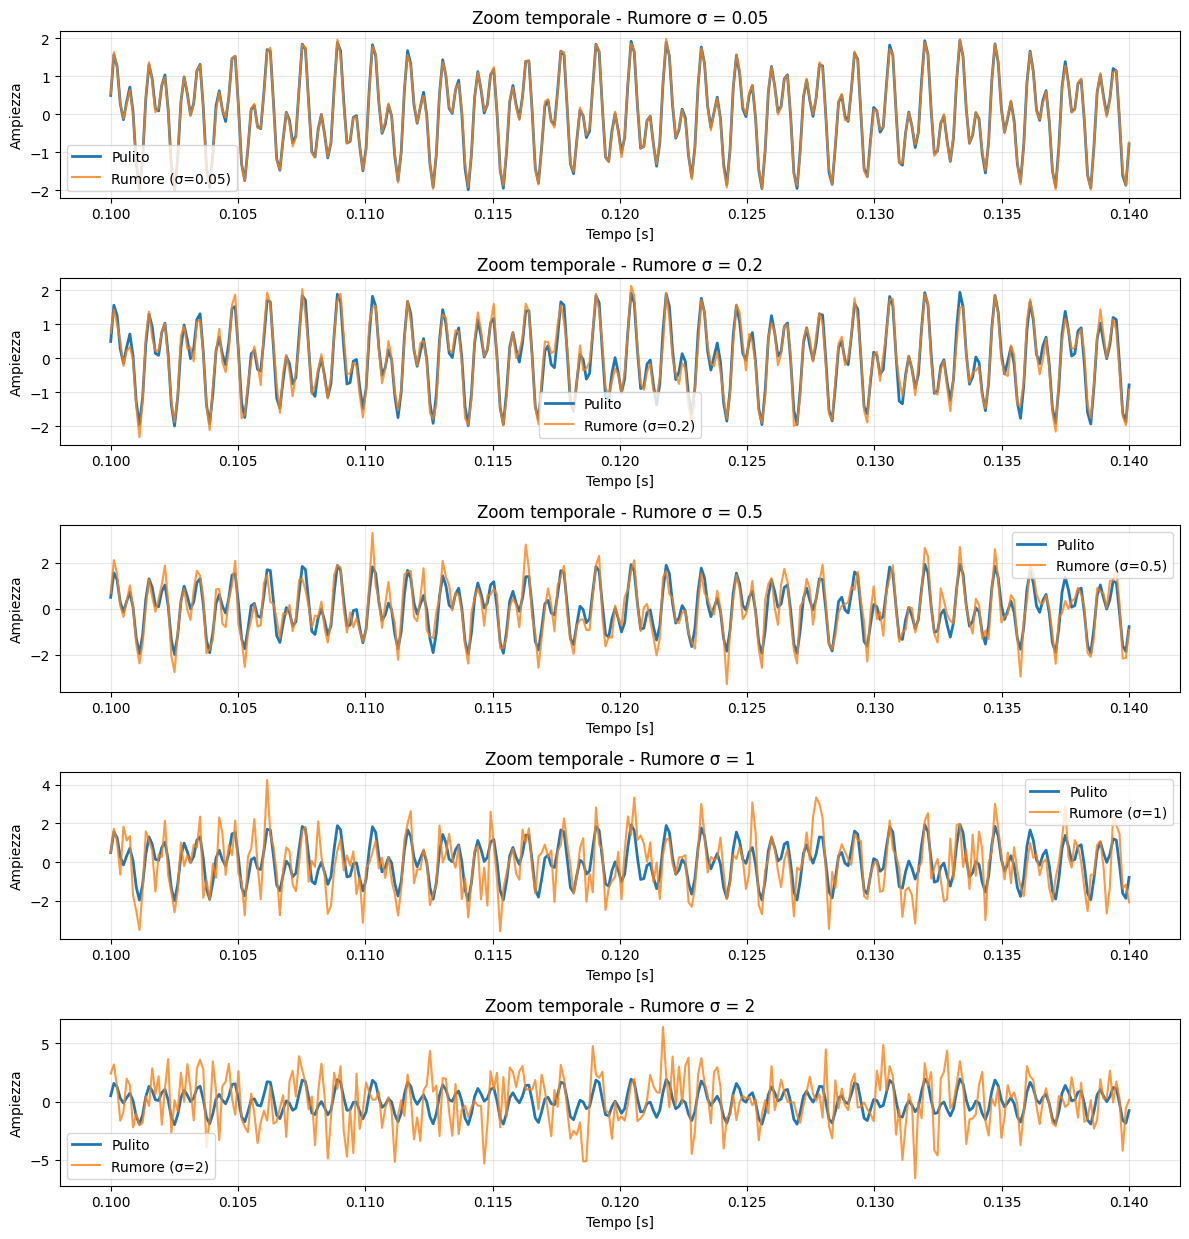


2. Test accuratezza al variare del rumore...
TEST ACCURATEZZA AL VARIARE DEL RUMORE

σ = 0


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Accuratezza: 100.0% (50000/50000)
SNR medio: nan dB

σ = 0.05
Accuratezza: 100.0% (50000/50000)
SNR medio: 26.0 dB

σ = 0.2
Accuratezza: 100.0% (50000/50000)
SNR medio: 14.0 dB

σ = 0.5
Accuratezza: 100.0% (50000/50000)
SNR medio: 6.0 dB

σ = 1
Accuratezza: 100.0% (50000/50000)
SNR medio: 0.0 dB

σ = 2
Accuratezza: 100.0% (49983/50000)
SNR medio: -6.0 dB

σ = 3
Accuratezza: 92.9% (46465/50000)
SNR medio: -9.5 dB

σ = 4
Accuratezza: 58.8% (29392/50000)
SNR medio: -12.0 dB

σ = 5
Accuratezza: 23.3% (11630/50000)
SNR medio: -14.0 dB

σ = 6
Accuratezza: 6.4% (3202/50000)
SNR medio: -15.6 dB
Grafico salvato: Plots/experiments/noise/accuracy_vs_sigma.pdf


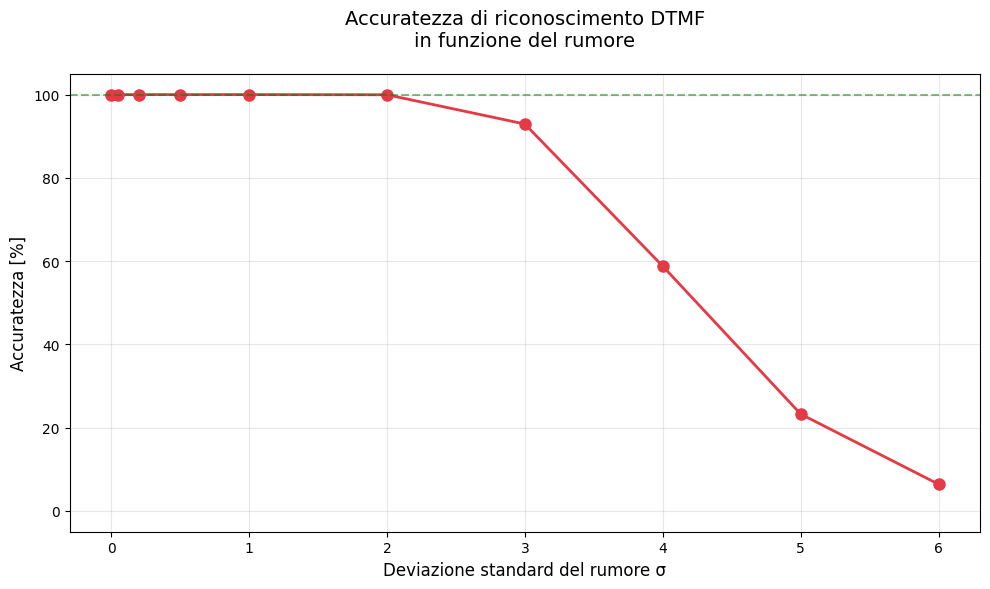

Grafico salvato: Plots/experiments/noise/accuracy_vs_snr.pdf


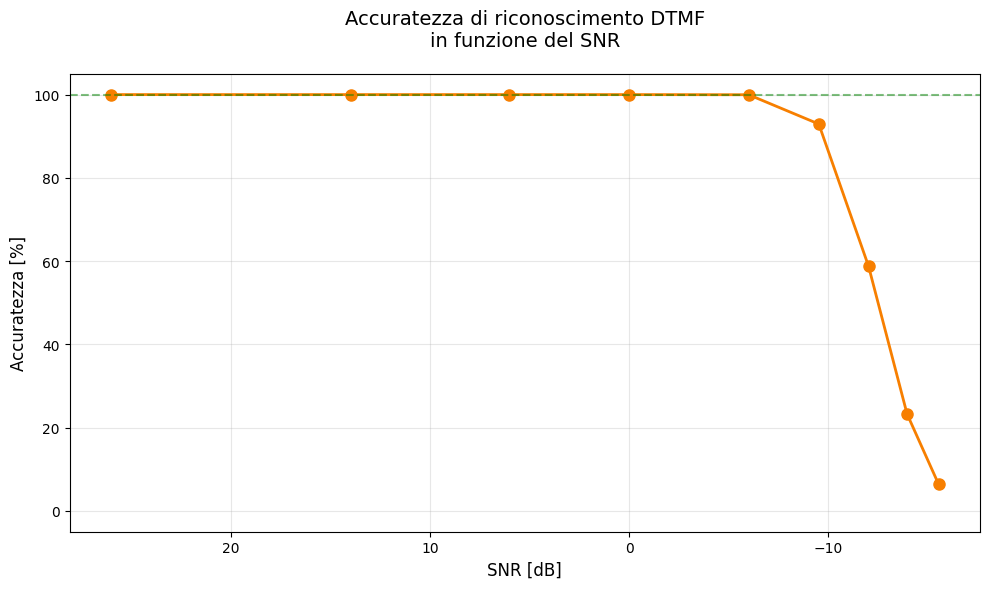

TABELLA RISULTATI
σ        SNR [dB]     Accuratezza [%]
----------------------------------------
0.00     ∞            100.0          
0.05     26.0         100.0          
0.20     14.0         100.0          
0.50     6.0          100.0          
1.00     0.0          100.0          
2.00     -6.0         100.0          
3.00     -9.5         92.9           
4.00     -12.0        58.8           
5.00     -14.0        23.3           
6.00     -15.6        6.4            

3. Test matrice durata × rumore...
TEST ACCURATEZZA: DURATA × RUMORE

--- Durata: 0.001s ---
  σ=0: 0.0%
  σ=0.5: 0.0%
  σ=1: 0.0%
  σ=2: 0.0%
  σ=3: 0.0%
  σ=4: 0.0%

--- Durata: 0.0016s ---
  σ=0: 0.0%
  σ=0.5: 0.0%
  σ=1: 0.0%
  σ=2: 0.0%
  σ=3: 0.0%
  σ=4: 0.0%

--- Durata: 0.0026s ---
  σ=0: 0.0%
  σ=0.5: 0.0%
  σ=1: 0.0%
  σ=2: 0.0%
  σ=3: 0.0%
  σ=4: 0.0%

--- Durata: 0.0042s ---
  σ=0: 0.0%
  σ=0.5: 0.0%
  σ=1: 0.0%
  σ=2: 0.0%
  σ=3: 0.0%
  σ=4: 0.0%

--- Durata: 0.0069s ---
  σ=0: 0.0%
  σ=0.5: 0.0%
  σ=1: 

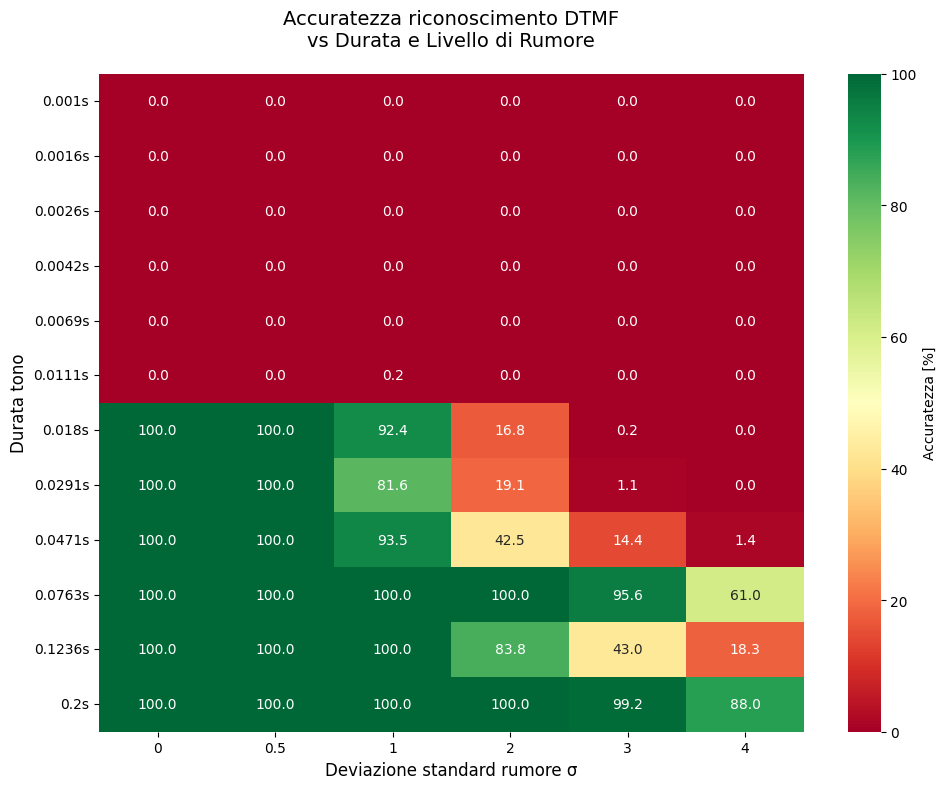


Tutti i risultati salvati in: Plots/experiments/noise/



In [13]:
# Esegui tutti gli esperimenti sul rumore
results = run_noise_experiments(
    sigmas=[0, 0.05, 0.2, 0.5, 1, 2, 3, 4, 5, 6],
    durations=durations,
    Fs=8000,
    n_sequences=1000,
    n_trials=50,
    plot_folder=PLOTS_NOISE
)

### **2.3 Variazione della frequenza di campionamento**

ESPERIMENTI: FREQUENZA DI CAMPIONAMENTO

1. Generazione confronti visivi...
Grafico salvato: Plots/experiments/sampling/sampling_comparison_3.pdf


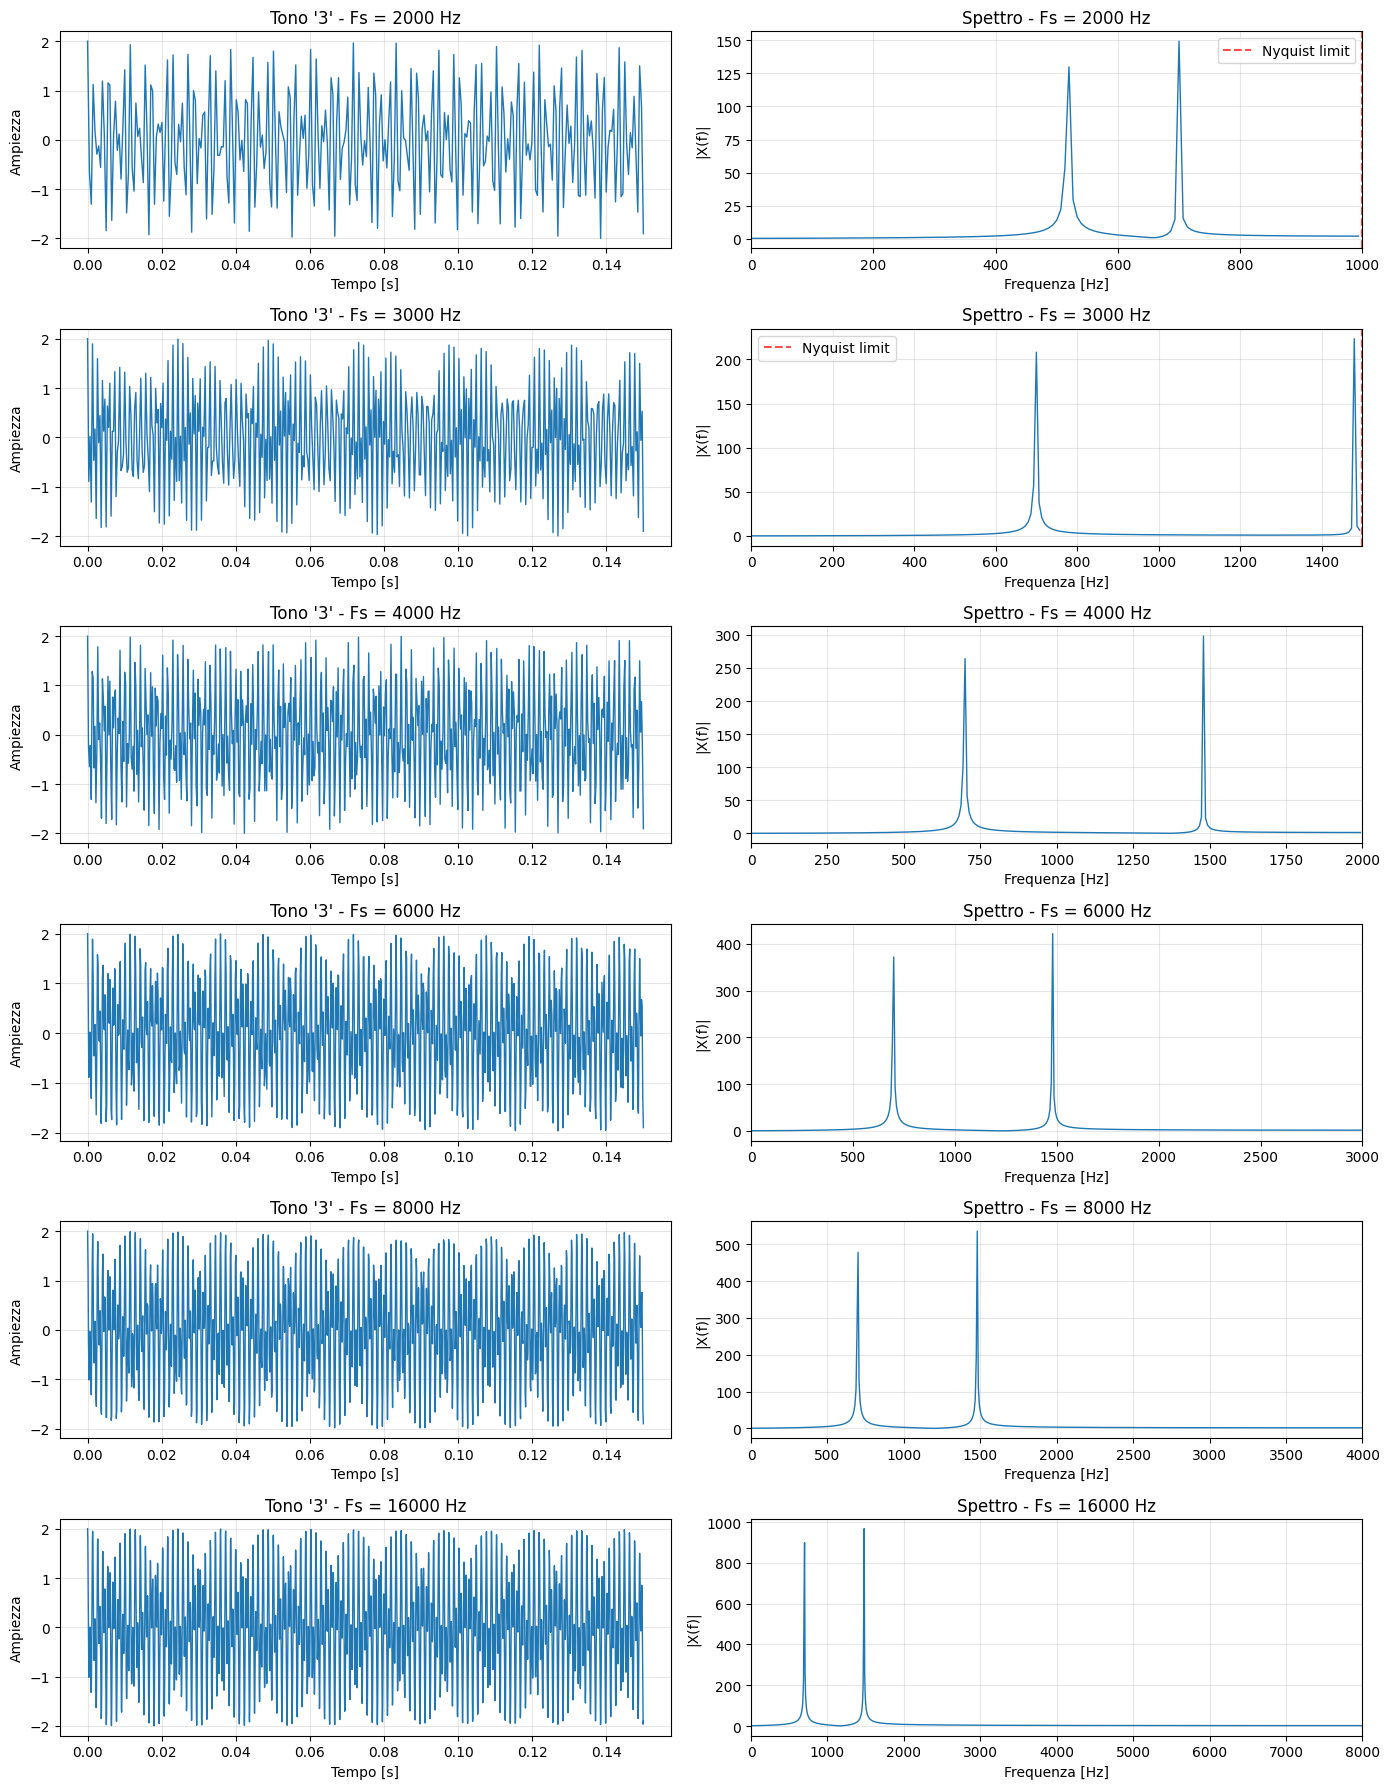

Grafico salvato: Plots/experiments/sampling/sampling_comparison_A.pdf


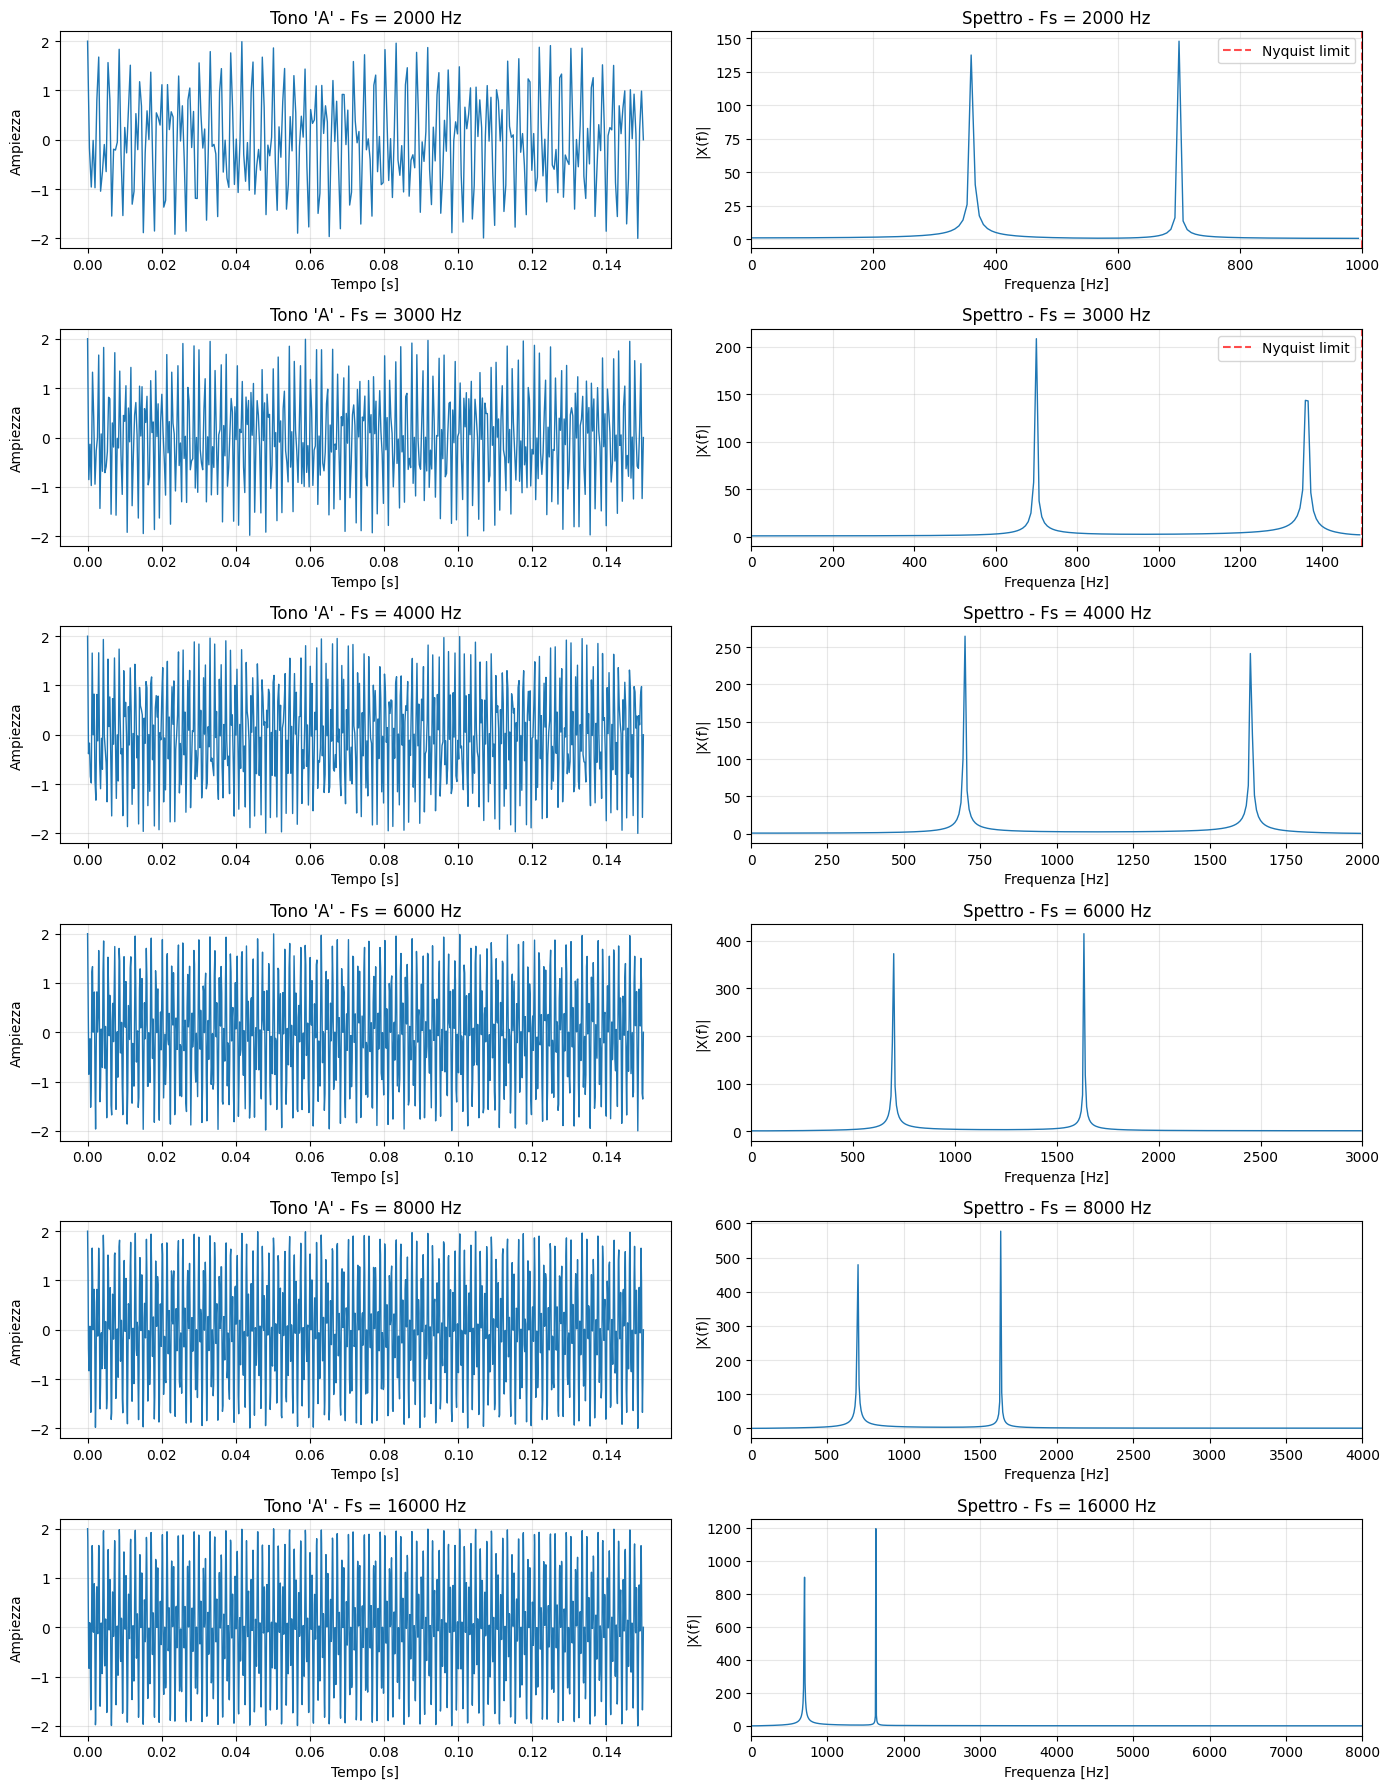

Grafico salvato: Plots/experiments/sampling/sampling_comparison_*.pdf


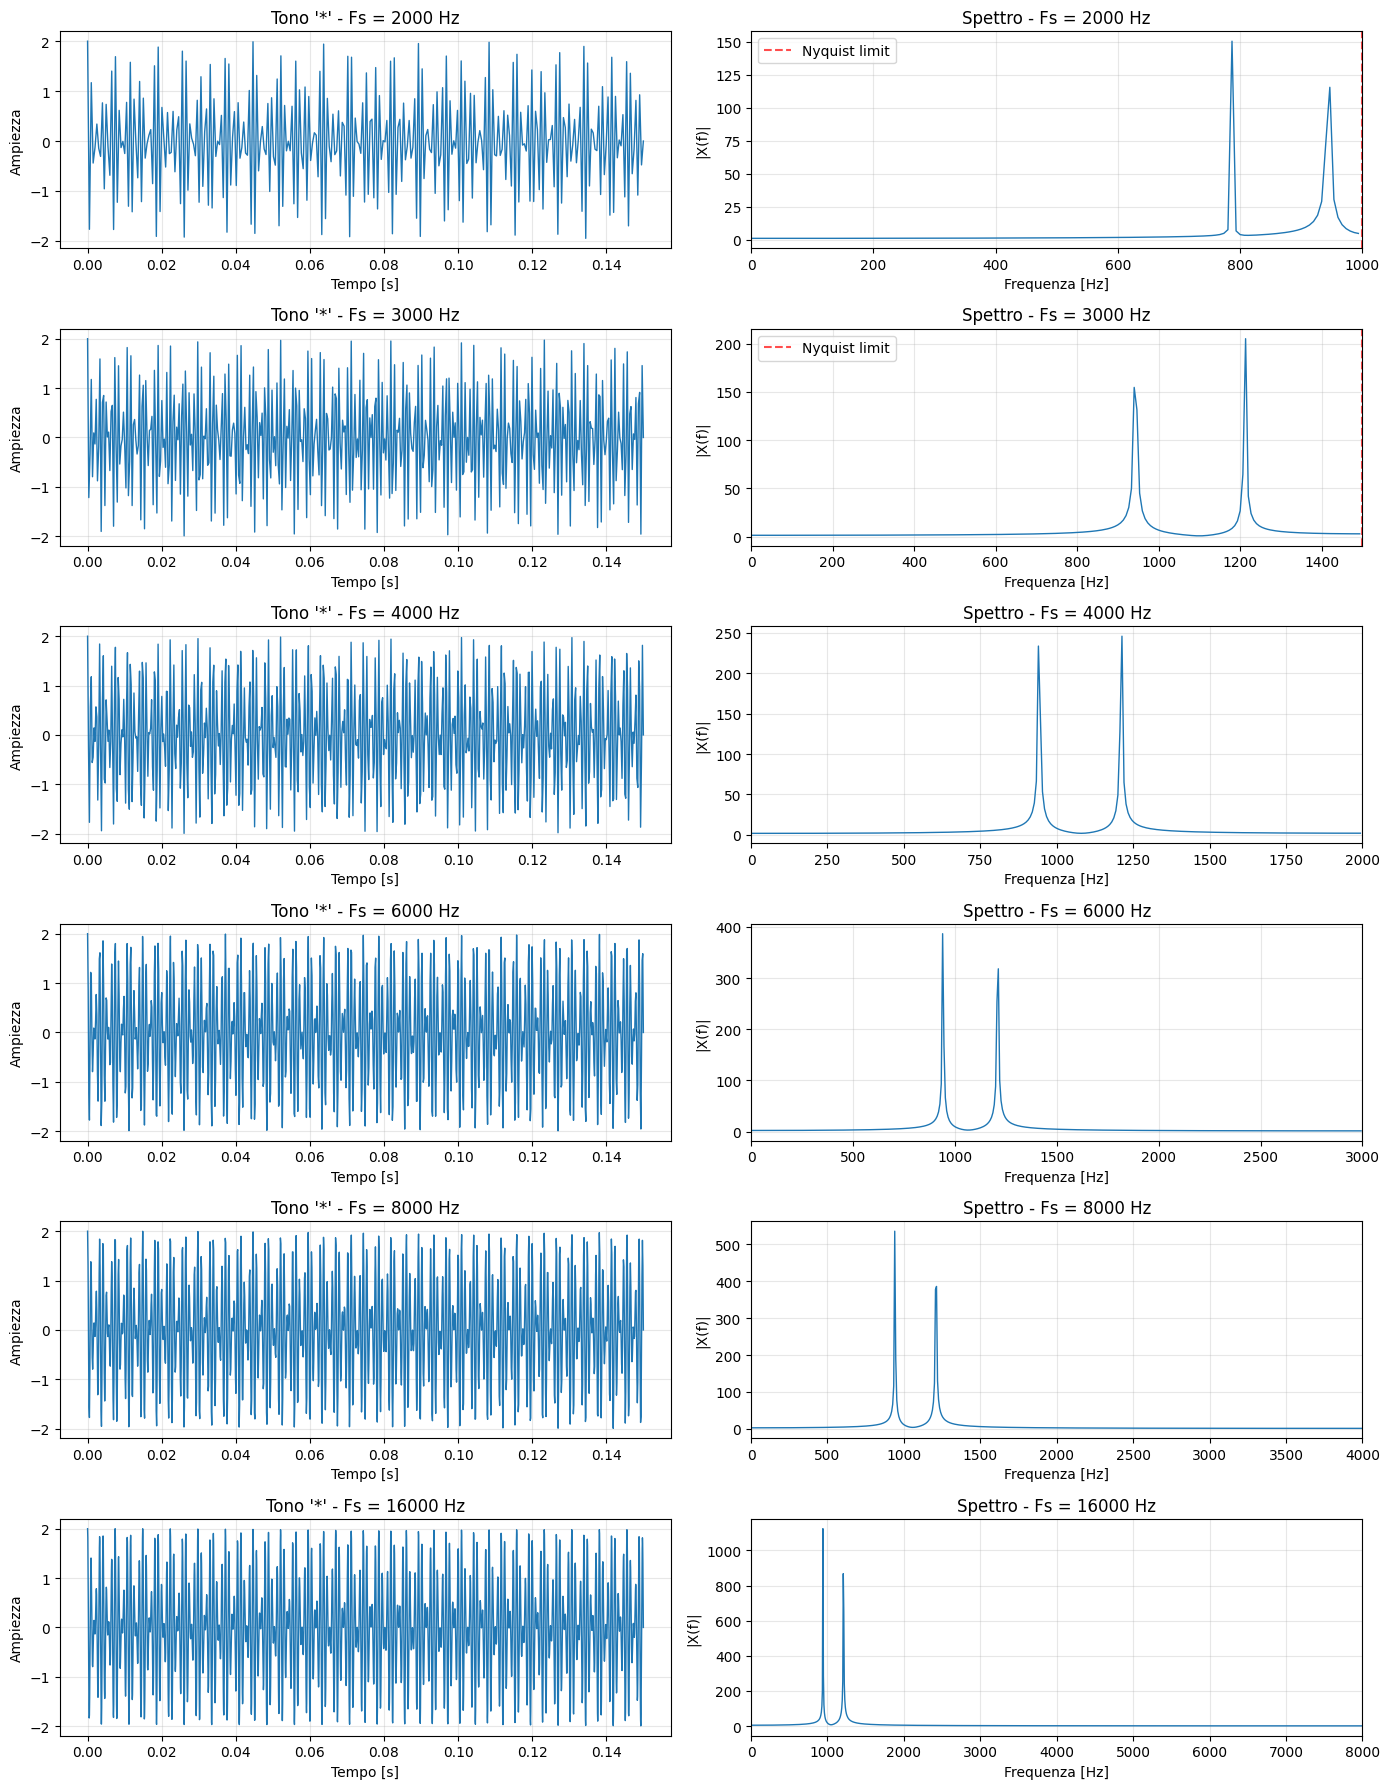


2. Dimostrazione fenomeno aliasing...
Grafico aliasing salvato: Plots/experiments/sampling/aliasing_demonstration.pdf


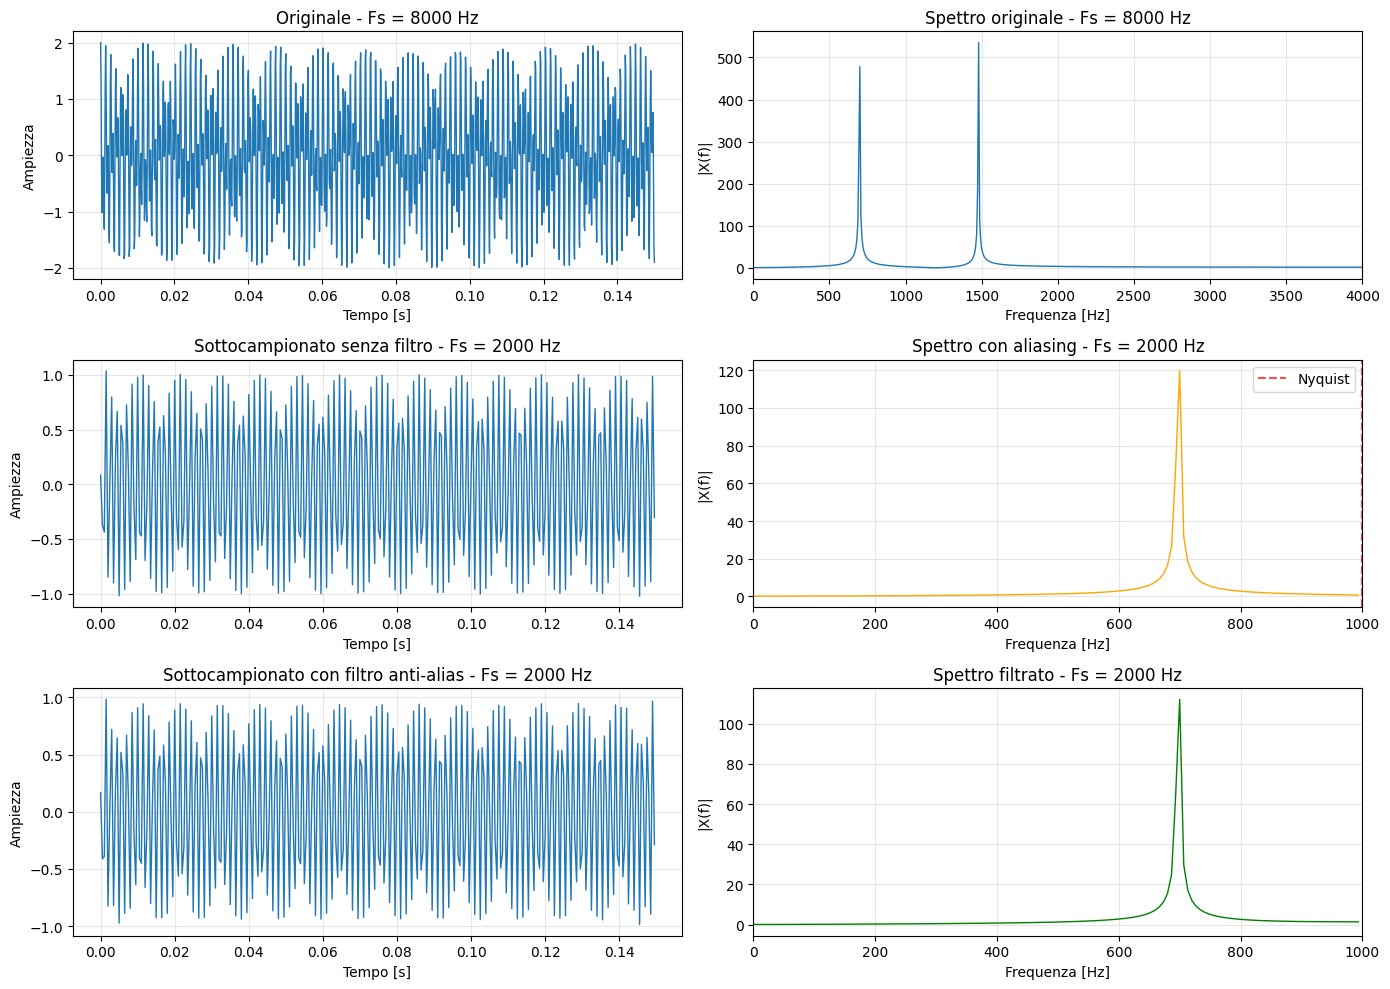


3. Test accuratezza vs frequenza di campionamento...

TEST ACCURATEZZA vs FREQUENZA DI CAMPIONAMENTO

Fs = 2000 Hz
Accuratezza: 0.0% (0/100)

Fs = 3000 Hz
Accuratezza: 7.0% (7/100)

Fs = 4000 Hz
Accuratezza: 100.0% (100/100)

Fs = 6000 Hz
Accuratezza: 100.0% (100/100)

Fs = 8000 Hz
Accuratezza: 100.0% (100/100)

Fs = 16000 Hz
Accuratezza: 100.0% (100/100)
Grafico salvato: Plots/experiments/sampling/accuracy_vs_fs.pdf


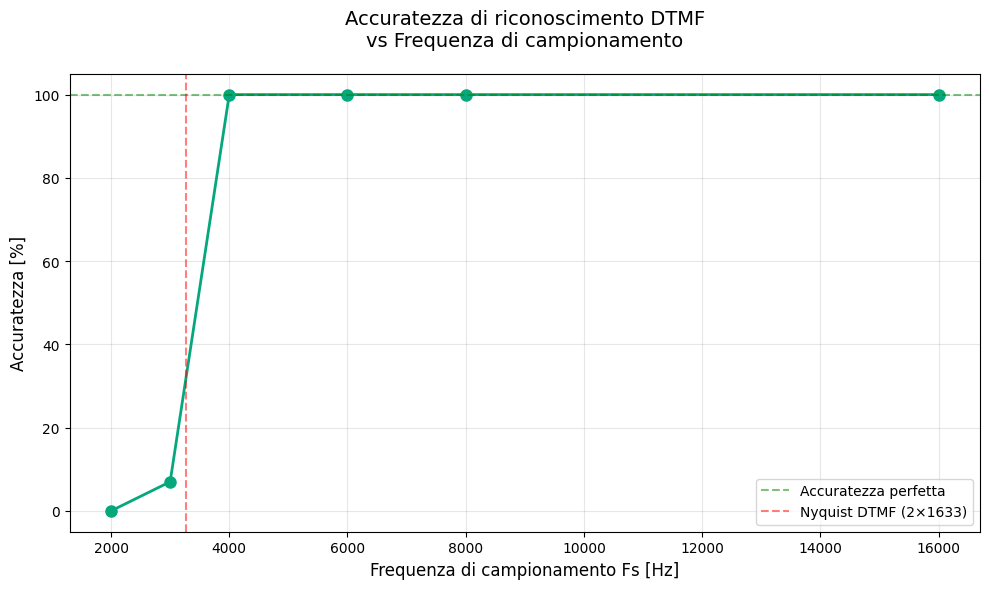


TABELLA RISULTATI
Fs [Hz]    Nyquist [Hz]    Accuratezza [%] Note                          
----------------------------------------------------------------------
2000       1000            0.0             Sotto Nyquist DTMF - Aliasing 
3000       1500            7.0             Sotto Nyquist DTMF - Aliasing 
4000       2000            100.0           OK                            
6000       3000            100.0           OK                            
8000       4000            100.0           OK                            
16000      8000            100.0           OK                            

DISCUSSIONE FENOMENO ALIASING

Il criterio di Nyquist richiede Fs >= 2 * f_max.
Per DTMF: f_max = 1633 Hz => Fs_min = 3266 Hz

Risultati osservati:
- Fs = 2000 Hz: Aliasing severo, accuratezza ~0%
- Fs = 3000 Hz: Nyquist soddisfatto ma risoluzione bassa
- Fs >= 4000 Hz: Riconoscimento affidabile

Il filtro anti-alias previene l'aliasing ma elimina
informazione utile quando Fs e' troppo ba

In [14]:
results = run_sampling_experiments(
    Fs_list=[2000, 3000, 4000, 6000, 8000, 16000],
    duration=0.15,
    n_sequences=100,
    plot_folder=PLOTS_SAMPLING
)

## **3. Miglioramenti dell'algoritmo**

### **3.1 Zero-padding**

In [ ]:
results = run_zeropadding_experiments(
    durations=[0.02, 0.05, 0.1, 0.15, 0.2],
    M_factors=[1, 2, 4, 8],
    Fs=8000,
    n_sequences=100,
    plot_folder=PLOTS_ZEROPADDING
)

### **3.2 Filtraggio segnale rumoroso**

In [ ]:
results = run_denoising_experiments(
    sigmas=[0, 0.5, 1, 2, 3, 4],
    Fs=8000,
    n_sequences=1000,
    plot_folder=PLOTS_DENOISING
)